In [ ]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


Preprocessing

In [ ]:
import os
import glob
import pandas as pd

# ==========================================================
# CONFIG
# ==========================================================

DATASET_ROOT = "/content/drive/MyDrive/MCI_dataset"

IMAGE_ROOT = os.path.join(DATASET_ROOT, "images/images")

LABEL_CSV = os.path.join(DATASET_ROOT, "label.csv")

# Use 25 to reproduce the paper exactly.
# Use 26 if continuing your previous experiments.
CUTOFF = 25

VALID_EXTENSIONS = (
    ".png",
    ".jpg",
    ".jpeg",
    ".bmp",
    ".tif",
    ".tiff",
)

IMAGE_KEYWORDS = {
    "clock": ["clock"],
    "copy": ["copy", "cube"],
    "trail": ["trail"],
}

# ==========================================================
# LOAD LABELS
# ==========================================================

def load_labels(csv_file):

    df = pd.read_csv(
        csv_file,
        dtype={"patient_id": str},
        sep=None,
        engine="python",
    )

    df.columns = [c.strip() for c in df.columns]

    df["patient_id"] = (
        df["patient_id"]
        .astype(str)
        .str.strip()
    )

    df["MoCA_score"] = pd.to_numeric(
        df["MoCA_score"],
        errors="coerce",
    )

    before = len(df)

    df = df.dropna(
        subset=["MoCA_score"]
    ).reset_index(drop=True)

    print(
        f"Removed {before-len(df)} patients with missing MoCA."
    )

    duplicates = df["patient_id"].duplicated()

    if duplicates.any():

        print(
            f"Removed {duplicates.sum()} duplicate patient IDs."
        )

        df = (
            df
            .drop_duplicates(
                subset="patient_id",
                keep="first",
            )
            .reset_index(drop=True)
        )

    df["label"] = (
        df["MoCA_score"] < CUTOFF
    ).astype(int)

    df["label_name"] = df["label"].map(
        {
            0: "Normal",
            1: "MCI",
        }
    )

    return df


# ==========================================================
# IMAGE SEARCH
# ==========================================================

def find_image(patient_folder, keywords):

    files = glob.glob(
        os.path.join(patient_folder, "**", "*"),
        recursive=True,
    )

    matches = []

    for f in files:

        if not os.path.isfile(f):
            continue

        ext = os.path.splitext(f)[1].lower()

        if ext not in VALID_EXTENSIONS:
            continue

        name = os.path.basename(f).lower()

        if any(k in name for k in keywords):
            matches.append(os.path.abspath(f))

    matches = sorted(matches)

    return matches


# ==========================================================
# BUILD INDEX
# ==========================================================

def build_dataset_index(labels_df):

    patient_folders = {
        x
        for x in os.listdir(IMAGE_ROOT)
        if os.path.isdir(os.path.join(IMAGE_ROOT, x))
    }

    rows = []

    missing_folder = []
    missing_images = []
    duplicate_images = []

    for _, row in labels_df.iterrows():

        pid = row["patient_id"]

        if pid not in patient_folders:

            missing_folder.append(pid)
            continue

        folder = os.path.join(
            IMAGE_ROOT,
            pid,
        )

        record = {

            "patient_id": pid,

            "MoCA_score": row["MoCA_score"],

            "label": row["label"],

            "label_name": row["label_name"],
        }

        complete = True

        for task, kws in IMAGE_KEYWORDS.items():

            imgs = find_image(folder, kws)

            if len(imgs) == 0:

                record[f"{task}_path"] = None

                complete = False

            else:

                record[f"{task}_path"] = imgs[0]

                record[f"{task}_file"] = os.path.basename(imgs[0])

                if len(imgs) > 1:

                    duplicate_images.append(
                        (pid, task, imgs)
                    )

        image_count = len(
            [
                x
                for x in glob.glob(
                    os.path.join(folder, "*")
                )
                if os.path.splitext(x)[1].lower()
                in VALID_EXTENSIONS
            ]
        )

        record["image_count"] = image_count

        if image_count != 3:
            missing_images.append(pid)

        rows.append(record)

    df = pd.DataFrame(rows)

    df = (
        df
        .sort_values("patient_id")
        .reset_index(drop=True)
    )

    print()

    print("=" * 60)

    print("DATASET REPORT")

    print("=" * 60)

    print(
        f"Patients indexed : {len(df)}"
    )

    print(
        f"Missing folders  : {len(missing_folder)}"
    )

    print(
        f"Wrong image count: {len(missing_images)}"
    )

    print(
        f"Duplicate images : {len(duplicate_images)}"
    )

    if missing_folder:

        print()

        print("Missing folders:")

        print(missing_folder)

    if missing_images:

        print()

        print("Patients with image count != 3")

        print(missing_images)

    if duplicate_images:

        print()

        print("Duplicate task images")

        for d in duplicate_images:
            print(d)

    return df


# ==========================================================
# MAIN
# ==========================================================

def main():

    labels = load_labels(LABEL_CSV)

    labels.to_csv(
        os.path.join(
            DATASET_ROOT,
            "labels_binary.csv",
        ),
        index=False,
    )

    print()

    print(labels["label_name"].value_counts())

    dataset = build_dataset_index(labels)

    dataset.to_csv(
        os.path.join(
            DATASET_ROOT,
            "dataset_index.csv",
        ),
        index=False,
    )

    complete = dataset.dropna(
        subset=[
            "clock_path",
            "copy_path",
            "trail_path",
        ]
    )

    print()

    print("=" * 60)

    print(
        f"Complete patients : {len(complete)} / {len(dataset)}"
    )

    print()

    print("Saved")

    print(
        os.path.join(
            DATASET_ROOT,
            "labels_binary.csv",
        )
    )

    print(
        os.path.join(
            DATASET_ROOT,
            "dataset_index.csv",
        )
    )


if __name__ == "__main__":
    main()

import os
import pandas as pd
from sklearn.model_selection import train_test_split

# ==========================================================
# CONFIG
# ==========================================================

DATASET_ROOT = "/content/drive/MyDrive/MCI_dataset"

INDEX_CSV = os.path.join(DATASET_ROOT, "dataset_index.csv")

SPLIT_DIR = os.path.join(DATASET_ROOT, "split")

TRAIN_FRAC = 0.70
VAL_FRAC = 0.15
TEST_FRAC = 0.15

RANDOM_SEED = 42

# ==========================================================


def print_distribution(df, name):

    counts = df["label_name"].value_counts().sort_index()

    print(f"\n{name}")

    print("-" * 40)

    print(counts)

    print()

    print((counts / len(df) * 100).round(2))


def verify_paths(df):

    missing = []

    for col in ["clock_path", "copy_path", "trail_path"]:

        bad = df[~df[col].apply(os.path.exists)]

        if len(bad):

            missing.extend(bad["patient_id"].tolist())

    if len(missing):

        raise RuntimeError(
            f"Missing image files for {len(set(missing))} patients."
        )


def leakage_check(train_df, val_df, test_df):

    train = set(train_df.patient_id)

    val = set(val_df.patient_id)

    test = set(test_df.patient_id)

    assert len(train & val) == 0

    assert len(train & test) == 0

    assert len(val & test) == 0


def main():

    assert abs(
        TRAIN_FRAC + VAL_FRAC + TEST_FRAC - 1
    ) < 1e-6

    df = pd.read_csv(
        INDEX_CSV,
        dtype={"patient_id": str},
    )

    df = df.drop_duplicates(
        subset="patient_id"
    ).reset_index(drop=True)

    df = df.dropna(
        subset=[
            "clock_path",
            "copy_path",
            "trail_path",
        ]
    )

    df = df.sort_values(
        "patient_id"
    ).reset_index(drop=True)

    verify_paths(df)

    print()

    print(f"Total patients : {len(df)}")

    print_distribution(df, "Complete Dataset")

    train_df, temp_df = train_test_split(
        df,
        test_size=VAL_FRAC + TEST_FRAC,
        stratify=df["label"],
        random_state=RANDOM_SEED,
    )

    test_ratio = TEST_FRAC / (VAL_FRAC + TEST_FRAC)

    val_df, test_df = train_test_split(
        temp_df,
        test_size=test_ratio,
        stratify=temp_df["label"],
        random_state=RANDOM_SEED,
    )

    train_df = train_df.reset_index(drop=True)

    val_df = val_df.reset_index(drop=True)

    test_df = test_df.reset_index(drop=True)

    leakage_check(
        train_df,
        val_df,
        test_df,
    )

    os.makedirs(
        SPLIT_DIR,
        exist_ok=True,
    )

    train_df.to_csv(
        os.path.join(SPLIT_DIR, "train.csv"),
        index=False,
    )

    val_df.to_csv(
        os.path.join(SPLIT_DIR, "val.csv"),
        index=False,
    )

    test_df.to_csv(
        os.path.join(SPLIT_DIR, "test.csv"),
        index=False,
    )

    print_distribution(train_df, "Train")

    print_distribution(val_df, "Validation")

    print_distribution(test_df, "Test")

    summary = pd.DataFrame(
        {
            "Split": [
                "Train",
                "Validation",
                "Test",
            ],
            "Patients": [
                len(train_df),
                len(val_df),
                len(test_df),
            ],
            "Normal": [
                (train_df.label == 0).sum(),
                (val_df.label == 0).sum(),
                (test_df.label == 0).sum(),
            ],
            "MCI": [
                (train_df.label == 1).sum(),
                (val_df.label == 1).sum(),
                (test_df.label == 1).sum(),
            ],
        }
    )

    summary.to_csv(
        os.path.join(
            SPLIT_DIR,
            "split_summary.csv",
        ),
        index=False,
    )

    print("\nFiles saved:")

    print(os.path.join(SPLIT_DIR, "train.csv"))

    print(os.path.join(SPLIT_DIR, "val.csv"))

    print(os.path.join(SPLIT_DIR, "test.csv"))

    print(os.path.join(SPLIT_DIR, "split_summary.csv"))


if __name__ == "__main__":
    main()

Removed 0 patients with missing MoCA.

label_name
Normal    651
MCI       267
Name: count, dtype: int64

DATASET REPORT
Patients indexed : 918
Missing folders  : 0
Wrong image count: 0
Duplicate images : 0

Complete patients : 918 / 918

Saved
/content/drive/MyDrive/MCI_dataset/labels_binary.csv
/content/drive/MyDrive/MCI_dataset/dataset_index.csv

Total patients : 918

Complete Dataset
----------------------------------------
label_name
MCI       267
Normal    651
Name: count, dtype: int64

label_name
MCI       29.08
Normal    70.92
Name: count, dtype: float64

Train
----------------------------------------
label_name
MCI       187
Normal    455
Name: count, dtype: int64

label_name
MCI       29.13
Normal    70.87
Name: count, dtype: float64

Validation
----------------------------------------
label_name
MCI       40
Normal    98
Name: count, dtype: int64

label_name
MCI       28.99
Normal    71.01
Name: count, dtype: float64

Test
----------------------------------------
label_name
M

Baseline Models

Densenet121

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Device : cuda
GPU : Tesla T4

Configuration
------------------------------------------------------------
Backbone        : densenet121
Image Size      : 224
Batch Size      : 16
Epochs          : 50
Learning Rate   : 0.0001
Weight Decay    : 0.0001
Unfreeze Frac.  : 0.3
Mixed Precision : True
------------------------------------------------------------
Run manifest saved to /content/drive/MyDrive/MCI_Results_densenet121/run_manifest.json

Train : 642
Validation : 138
Test : 138

            patient_id  MoCA_score  label label_name  \
0   741365287116041472          24      1        MCI   
1   337140389762916207          30      0     Normal   
2  6386301594803982624          27      0     Normal   
3  6211790656715700606          29      0     Normal   
4   440601492270586615          30      0     Normal   

                                          clock_pa

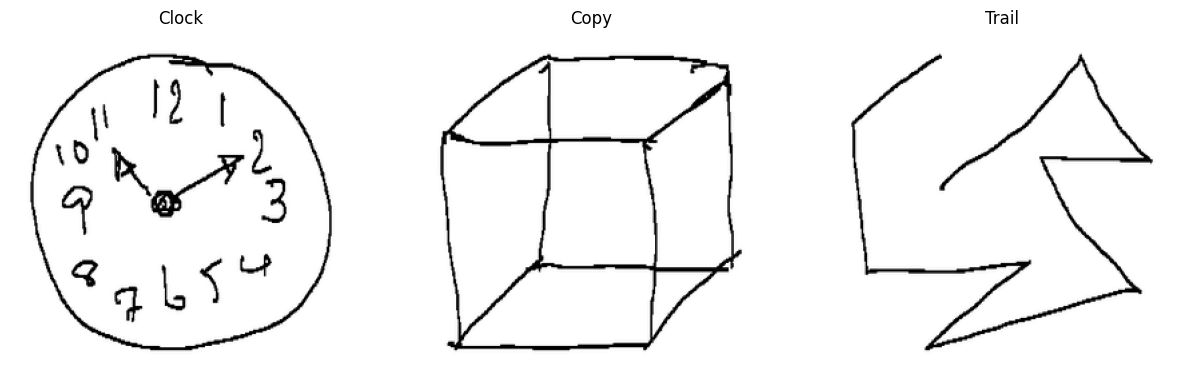

Label : 1
MoCA : 24.0
Train : 642 patients
Validation : 138 patients
Test : 138 patients

Class Weights
tensor([0.7055, 1.7166], device='cuda:0')

Batch Shapes
Clock : torch.Size([16, 3, 224, 224])
Copy  : torch.Size([16, 3, 224, 224])
Trail : torch.Size([16, 3, 224, 224])
Label : torch.Size([16])
Downloading: "https://download.pytorch.org/models/densenet121-a639ec97.pth" to /root/.cache/torch/hub/checkpoints/densenet121-a639ec97.pth


100%|██████████| 30.8M/30.8M [00:00<00:00, 189MB/s]


Model Summary
Backbone : densenet121
Trainable Parameters : 7,170,690
Total Parameters     : 8,600,322
Training Components Ready
Loss Function : FocalLoss
Optimizer     : AdamW
Scheduler     : ReduceLROnPlateau
EarlyStopping : Patience = 10
Training Started


  0%|          | 0/40 [01:35<?, ?it/s]

  0%|          | 0/9 [00:00<?, ?it/s]

...

Epoch 11/50 | Train Loss 0.1536 | Train Acc 0.6422 | Val Loss 0.4461 | Val Acc 0.7826 | Val AUC 0.7862 | LR 2.50e-05
EarlyStopping: 10/10

Early stopping activated.

Training Finished
Best Validation AUC : 0.8111
Loading Best Model


  0%|          | 0/9 [00:00<?, ?it/s]


Best Threshold = 0.34
Validation F1 = 0.6118


  0%|          | 0/9 [00:00<?, ?it/s]


TEST RESULTS
Threshold   : 0.34
Test Loss   : 0.4043
Accuracy    : 0.7391
Precision   : 0.5588
Recall      : 0.4750
Specificity : 0.8469
F1 Score    : 0.5135
ROC AUC     : 0.7219

Confusion Matrix
[[83 15]
 [21 19]]

Classification Report

              precision    recall  f1-score   support

      Normal       0.80      0.85      0.82        98
         MCI       0.56      0.47      0.51        40

    accuracy                           0.74       138
   macro avg       0.68      0.66      0.67       138
weighted avg       0.73      0.74      0.73       138


Metrics saved to
/content/drive/MyDrive/MCI_Results_densenet121/test_metrics.csv


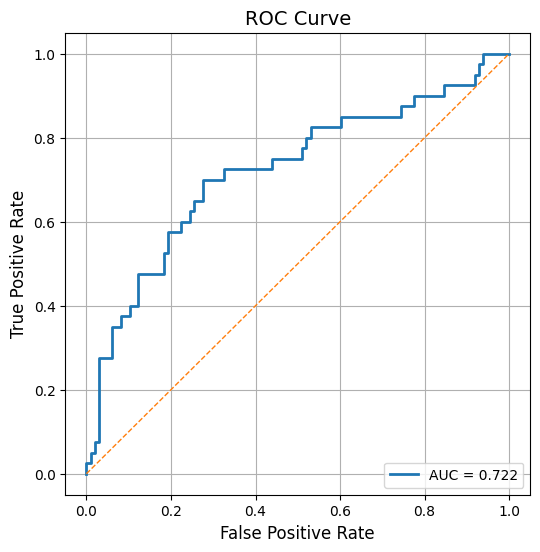

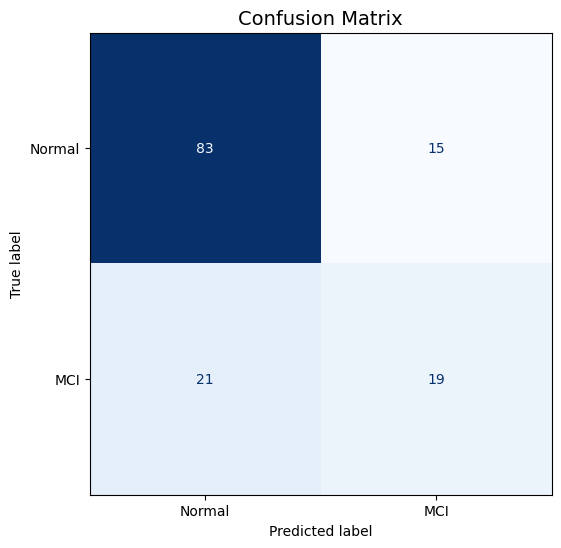

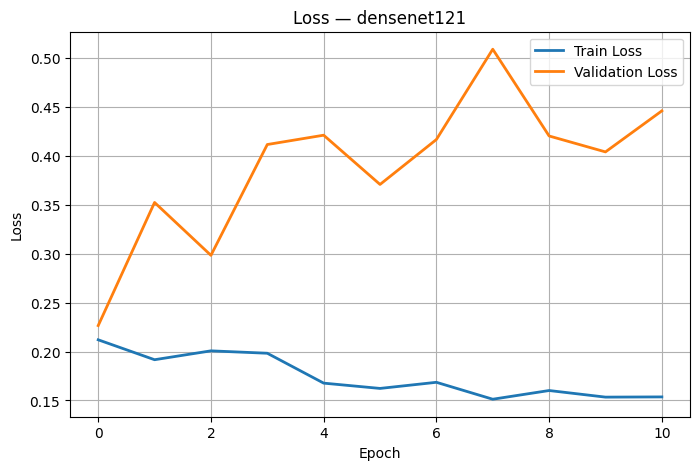

Results Saved
ROC Curve          : /content/drive/MyDrive/MCI_Results_densenet121/roc_curve.png
Confusion Matrix   : /content/drive/MyDrive/MCI_Results_densenet121/confusion_matrix.png
Predictions CSV    : /content/drive/MyDrive/MCI_Results_densenet121/test_predictions.csv
Loss Curve         : /content/drive/MyDrive/MCI_Results_densenet121/loss_curve.png
Metrics CSV        : /content/drive/MyDrive/MCI_Results_densenet121/test_metrics.csv


In [ ]:

# -----------------------------
# Standard libraries
# -----------------------------
import os, json, random, warnings, platform
import numpy as np
import pandas as pd
from PIL import Image

warnings.filterwarnings("ignore")

# -----------------------------
# PyTorch / TorchVision
# -----------------------------
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torch.cuda.amp import autocast, GradScaler

import torchvision
from torchvision import transforms
import torchvision.models as models

# -----------------------------
# Sklearn
# -----------------------------
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, classification_report,
    roc_curve, auc, ConfusionMatrixDisplay,
)
from sklearn.utils.class_weight import compute_class_weight

# -----------------------------
# Viz / progress
# -----------------------------
import matplotlib.pyplot as plt
from tqdm.auto import tqdm

# ==========================================================
# SEED / DEVICE
# ==========================================================

SEED = 42
random.seed(SEED); np.random.seed(SEED)
torch.manual_seed(SEED); torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("=" * 60)
print("Device :", DEVICE)
if DEVICE.type == "cuda":
    print("GPU :", torch.cuda.get_device_name(0))
print("=" * 60)

# ==========================================================
# PATHS
# ==========================================================

DATASET_ROOT = "/content/drive/MyDrive/MCI_dataset"
TRAIN_CSV = os.path.join(DATASET_ROOT, "split/train.csv")
VAL_CSV   = os.path.join(DATASET_ROOT, "split/val.csv")
TEST_CSV  = os.path.join(DATASET_ROOT, "split/test.csv")

# ==========================================================
# MODEL / TRAINING CONFIG — change BACKBONE for experiments
# ==========================================================

BACKBONE = "densenet121"      # "efficientnet_b3" or "densenet121"
OUTPUT_DIR = f"/content/drive/MyDrive/MCI_Results_{BACKBONE}"
os.makedirs(OUTPUT_DIR, exist_ok=True)
CHECKPOINT_PATH = os.path.join(OUTPUT_DIR, "best_model.pth")

NUM_CLASSES = 2
IMAGE_SIZE = 300 if BACKBONE == "efficientnet_b3" else 224
BATCH_SIZE = 16
NUM_WORKERS = 2
EPOCHS = 50
LEARNING_RATE = 1e-4
WEIGHT_DECAY = 1e-4
UNFREEZE_FRACTION = 0.30       # fraction of backbone conv-block stack to fine-tune
GRAD_CLIP_NORM = 1.0
EARLY_STOPPING_PATIENCE = 10
USE_AMP = torch.cuda.is_available()

print("\nConfiguration")
print("-" * 60)
print(f"Backbone        : {BACKBONE}")
print(f"Image Size      : {IMAGE_SIZE}")
print(f"Batch Size      : {BATCH_SIZE}")
print(f"Epochs          : {EPOCHS}")
print(f"Learning Rate   : {LEARNING_RATE}")
print(f"Weight Decay    : {WEIGHT_DECAY}")
print(f"Unfreeze Frac.  : {UNFREEZE_FRACTION}")
print(f"Mixed Precision : {USE_AMP}")
print("-" * 60)


def save_run_manifest():
    manifest = {
        "backbone": BACKBONE, "seed": SEED, "image_size": IMAGE_SIZE,
        "batch_size": BATCH_SIZE, "epochs": EPOCHS,
        "unfreeze_fraction": UNFREEZE_FRACTION,
        "learning_rate": LEARNING_RATE, "weight_decay": WEIGHT_DECAY,
        "grad_clip_norm": GRAD_CLIP_NORM,
        "torch_version": torch.__version__,
        "torchvision_version": torchvision.__version__,
        "python_version": platform.python_version(),
        "cuda_available": torch.cuda.is_available(),
        "gpu_name": torch.cuda.get_device_name(0) if torch.cuda.is_available() else None,
    }
    with open(os.path.join(OUTPUT_DIR, "run_manifest.json"), "w") as f:
        json.dump(manifest, f, indent=2)
    print("Run manifest saved to", os.path.join(OUTPUT_DIR, "run_manifest.json"))


save_run_manifest()

# ==========================================================
# DATASET
# ==========================================================

class MCIDataset(Dataset):
    def __init__(self, csv_file, transform=None):
        self.df = pd.read_csv(csv_file, dtype={"patient_id": str}).reset_index(drop=True)
        self.transform = transform
        print(f"{os.path.basename(csv_file)} : {len(self.df)} patients")

    def __len__(self):
        return len(self.df)

    def load_image(self, image_path):
        image = Image.open(image_path).convert("RGB")
        if self.transform is not None:
            image = self.transform(image)
        return image

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        return {
            "patient_id": row["patient_id"],
            "clock": self.load_image(row["clock_path"]),
            "copy": self.load_image(row["copy_path"]),
            "trail": self.load_image(row["trail_path"]),
            "label": torch.tensor(int(row["label"]), dtype=torch.long),
            "moca": float(row["MoCA_score"]),
        }


train_df = pd.read_csv(TRAIN_CSV)
val_df = pd.read_csv(VAL_CSV)
test_df = pd.read_csv(TEST_CSV)

print()
print("Train :", len(train_df))
print("Validation :", len(val_df))
print("Test :", len(test_df))
print()
print(train_df.head())

# ==========================================================
# TRANSFORMS
# NOTE: no RandomHorizontalFlip — clock numerals and trail
# direction are semantically meaningful and mirroring them
# would corrupt the diagnostic signal.
# ==========================================================

IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD = [0.229, 0.224, 0.225]

train_transform = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.RandomRotation(10),
    transforms.RandomAffine(degrees=0, translate=(0.05, 0.05), scale=(0.9, 1.1)),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(),
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
])

val_transform = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
])

train_dataset = MCIDataset(TRAIN_CSV, transform=train_transform)
val_dataset   = MCIDataset(VAL_CSV,   transform=val_transform)
test_dataset  = MCIDataset(TEST_CSV,  transform=val_transform)

# Sanity check — transformed sample should be a tensor
sample = train_dataset[0]
print()
print(sample["patient_id"], sample["label"], sample["moca"])
print(type(sample["clock"]), type(sample["copy"]), type(sample["trail"]))

# Preview raw (untransformed) images from a separate dataset instance
preview_dataset = MCIDataset(TRAIN_CSV, transform=None)
patient = preview_dataset[0]

plt.figure(figsize=(15, 5))
plt.subplot(1, 3, 1); plt.imshow(patient["clock"]); plt.title("Clock"); plt.axis("off")
plt.subplot(1, 3, 2); plt.imshow(patient["copy"]);  plt.title("Copy");  plt.axis("off")
plt.subplot(1, 3, 3); plt.imshow(patient["trail"]); plt.title("Trail"); plt.axis("off")
plt.show()
print("Label :", patient["label"].item())
print("MoCA :", patient["moca"])

# ==========================================================
# DATALOADERS
# drop_last=True on TRAIN ONLY: the classifier head has
# BatchNorm1d layers, which crash on a batch of size 1. A
# size-1 final batch happens whenever
# len(train_dataset) % BATCH_SIZE == 1 — silent otherwise.
# Val/test keep every sample since we want every prediction
# for correct metrics, and eval-mode BatchNorm uses running
# stats so a small last batch there is not a problem.
# ==========================================================

PIN_MEMORY = True

train_loader = DataLoader(
    train_dataset, batch_size=BATCH_SIZE, shuffle=True,
    num_workers=NUM_WORKERS, pin_memory=PIN_MEMORY,
    persistent_workers=(NUM_WORKERS > 0), drop_last=True,
)
val_loader = DataLoader(
    val_dataset, batch_size=BATCH_SIZE, shuffle=False,
    num_workers=NUM_WORKERS, pin_memory=PIN_MEMORY,
    persistent_workers=(NUM_WORKERS > 0),
)
test_loader = DataLoader(
    test_dataset, batch_size=BATCH_SIZE, shuffle=False,
    num_workers=NUM_WORKERS, pin_memory=PIN_MEMORY,
    persistent_workers=(NUM_WORKERS > 0),
)

print(f"Train : {len(train_dataset)} patients")
print(f"Validation : {len(val_dataset)} patients")
print(f"Test : {len(test_dataset)} patients")

class_weights = compute_class_weight(
    class_weight="balanced", classes=np.unique(train_df["label"]), y=train_df["label"]
)
class_weights = torch.tensor(class_weights, dtype=torch.float32, device=DEVICE)
print("\nClass Weights"); print(class_weights)

batch = next(iter(train_loader))
print("\nBatch Shapes")
print("Clock :", batch["clock"].shape)
print("Copy  :", batch["copy"].shape)
print("Trail :", batch["trail"].shape)
print("Label :", batch["label"].shape)

# ==========================================================
# MODEL
# ==========================================================

def build_backbone(name):
    if name.lower() == "efficientnet_b3":
        weights = models.EfficientNet_B3_Weights.IMAGENET1K_V1
        backbone = models.efficientnet_b3(weights=weights)
        feature_dim = backbone.classifier[1].in_features
        backbone.classifier = nn.Identity()
    elif name.lower() == "densenet121":
        weights = models.DenseNet121_Weights.IMAGENET1K_V1
        backbone = models.densenet121(weights=weights)
        feature_dim = backbone.classifier.in_features
        backbone.classifier = nn.Identity()
    else:
        raise ValueError("Unsupported backbone")
    return backbone, feature_dim


class MCIClassifier(nn.Module):

    def __init__(self, backbone_name="efficientnet_b3", num_classes=2,
                 unfreeze_fraction=0.30):
        super().__init__()

        self.backbone_name = backbone_name.lower()
        self.backbone, feature_dim = build_backbone(backbone_name)

        # Freeze everything first.
        for param in self.backbone.parameters():
            param.requires_grad = False

        # FIX: unfreeze the last `unfreeze_fraction` of the actual
        # conv-block stack under backbone.features — NOT
        # backbone.children(), which for EfficientNet/DenseNet is
        # only 2-3 top-level blocks (features/avgpool/classifier).
        # Using backbone.children() silently unfreezes only the
        # empty Identity() classifier and leaves every conv layer
        # frozen — i.e. no real fine-tuning happens at all.
        feature_children = list(self.backbone.features.children())
        n = len(feature_children)
        start = int(n * (1 - unfreeze_fraction))
        for child in feature_children[start:]:
            for param in child.parameters():
                param.requires_grad = True

        fusion_dim = feature_dim * 3
        self.classifier = nn.Sequential(
            nn.BatchNorm1d(fusion_dim), nn.Dropout(0.50),
            nn.Linear(fusion_dim, 512), nn.ReLU(inplace=True),
            nn.BatchNorm1d(512), nn.Dropout(0.40),
            nn.Linear(512, 128), nn.ReLU(inplace=True),
            nn.Dropout(0.30), nn.Linear(128, num_classes),
        )

    def forward(self, clock, copy, trail):
        # Calling self.backbone(x) directly is correct here: both
        # EfficientNet's and DenseNet's own forward() already do
        # pool -> flatten -> classifier(Identity) internally, so no
        # manual pooling step is needed (unlike scripts that call
        # backbone.features(x) directly, which skips that step).
        f1 = self.backbone(clock)
        f2 = self.backbone(copy)
        f3 = self.backbone(trail)
        fusion = torch.cat([f1, f2, f3], dim=1)
        return self.classifier(fusion)


model = MCIClassifier(BACKBONE, NUM_CLASSES, UNFREEZE_FRACTION).to(DEVICE)

trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
total = sum(p.numel() for p in model.parameters())
print("=" * 60)
print("Model Summary")
print("=" * 60)
print("Backbone :", BACKBONE)
print(f"Trainable Parameters : {trainable:,}")
print(f"Total Parameters     : {total:,}")
print("=" * 60)

# ==========================================================
# LOSS / OPTIMIZER / SCHEDULER
# ==========================================================

class FocalLoss(nn.Module):
    def __init__(self, alpha=None, gamma=2.0, reduction="mean"):
        super().__init__()
        self.alpha, self.gamma, self.reduction = alpha, gamma, reduction

    def forward(self, inputs, targets):
        ce_loss = nn.functional.cross_entropy(inputs, targets, weight=self.alpha, reduction="none")
        pt = torch.exp(-ce_loss)
        focal_loss = ((1 - pt) ** self.gamma) * ce_loss
        if self.reduction == "mean":
            return focal_loss.mean()
        elif self.reduction == "sum":
            return focal_loss.sum()
        return focal_loss


criterion = FocalLoss(alpha=class_weights, gamma=2.0)

optimizer = optim.AdamW(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY,
)

scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode="min", factor=0.5, patience=3)
scaler = GradScaler(enabled=USE_AMP)


class EarlyStopping:
    def __init__(self, patience=10, min_delta=0.0):
        self.patience, self.min_delta = patience, min_delta
        self.counter, self.best_loss, self.stop = 0, float("inf"), False

    def __call__(self, val_loss):
        if val_loss < self.best_loss - self.min_delta:
            self.best_loss, self.counter = val_loss, 0
        else:
            self.counter += 1
            print(f"EarlyStopping: {self.counter}/{self.patience}")
            if self.counter >= self.patience:
                self.stop = True


early_stopping = EarlyStopping(patience=EARLY_STOPPING_PATIENCE)
history = {"train_loss": [], "train_acc": [], "val_loss": [], "val_acc": [], "val_auc": [], "lr": []}

print("=" * 60)
print("Training Components Ready")
print("=" * 60)
print("Loss Function :", criterion.__class__.__name__)
print("Optimizer     : AdamW")
print("Scheduler     : ReduceLROnPlateau")
print("EarlyStopping : Patience =", early_stopping.patience)
print("=" * 60)

# ==========================================================
# TRAIN / VALIDATE
# ==========================================================

def train_one_epoch(model, loader):
    model.train()
    running_loss, running_correct, total = 0.0, 0, 0
    loop = tqdm(loader, leave=False)
    for batch in loop:
        clock = batch["clock"].to(DEVICE, non_blocking=True)
        copy = batch["copy"].to(DEVICE, non_blocking=True)
        trail = batch["trail"].to(DEVICE, non_blocking=True)
        labels = batch["label"].to(DEVICE)

        optimizer.zero_grad()
        with autocast(enabled=USE_AMP):
            outputs = model(clock, copy, trail)
            loss = criterion(outputs, labels)

        scaler.scale(loss).backward()
        # Grad clipping for stability — must unscale first when using AMP.
        scaler.unscale_(optimizer)
        torch.nn.utils.clip_grad_norm_(model.parameters(), GRAD_CLIP_NORM)
        scaler.step(optimizer)
        scaler.update()

        preds = outputs.argmax(dim=1)
        running_loss += loss.item() * labels.size(0)
        running_correct += (preds == labels).sum().item()
        total += labels.size(0)
        loop.set_postfix(loss=f"{loss.item():.4f}", acc=f"{100*running_correct/total:.2f}%")

    return running_loss / total, running_correct / total


def validate(model, loader):
    model.eval()
    running_loss, running_correct, total = 0.0, 0, 0
    y_true, y_prob = [], []
    with torch.no_grad():
        for batch in tqdm(loader, leave=False):
            clock = batch["clock"].to(DEVICE, non_blocking=True)
            copy = batch["copy"].to(DEVICE, non_blocking=True)
            trail = batch["trail"].to(DEVICE, non_blocking=True)
            labels = batch["label"].to(DEVICE)

            with autocast(enabled=USE_AMP):
                outputs = model(clock, copy, trail)
                loss = criterion(outputs, labels)

            probs = torch.softmax(outputs, dim=1)
            preds = outputs.argmax(dim=1)
            running_loss += loss.item() * labels.size(0)
            running_correct += (preds == labels).sum().item()
            total += labels.size(0)
            y_true.extend(labels.cpu().numpy())
            y_prob.extend(probs[:, 1].cpu().numpy())

    try:
        epoch_auc = roc_auc_score(y_true, y_prob)
    except Exception:
        epoch_auc = 0.5

    return running_loss / total, running_correct / total, epoch_auc


# ==========================================================
# TRAINING LOOP
# ==========================================================

print("=" * 70); print("Training Started"); print("=" * 70)
best_auc = 0.0

for epoch in range(EPOCHS):
    train_loss, train_acc = train_one_epoch(model, train_loader)
    val_loss, val_acc, val_auc = validate(model, val_loader)
    scheduler.step(val_loss)

    history["train_loss"].append(train_loss)
    history["train_acc"].append(train_acc)
    history["val_loss"].append(val_loss)
    history["val_acc"].append(val_acc)
    history["val_auc"].append(val_auc)
    history["lr"].append(optimizer.param_groups[0]["lr"])

    print(
        f"Epoch {epoch+1:02d}/{EPOCHS}"
        f" | Train Loss {train_loss:.4f}"
        f" | Train Acc {train_acc:.4f}"
        f" | Val Loss {val_loss:.4f}"
        f" | Val Acc {val_acc:.4f}"
        f" | Val AUC {val_auc:.4f}"
        f" | LR {optimizer.param_groups[0]['lr']:.2e}"
    )

    if val_auc > best_auc:
        best_auc = val_auc
        torch.save(model.state_dict(), CHECKPOINT_PATH)
        print("★★★★★ Best Model Updated ★★★★★")

    early_stopping(val_loss)
    if early_stopping.stop:
        print("\nEarly stopping activated.")
        break

print("\n" + "=" * 70)
print("Training Finished")
print("=" * 70)
print(f"Best Validation AUC : {best_auc:.4f}")

# ==========================================================
# TEST EVALUATION (threshold tuned on val)
# ==========================================================

print("=" * 60); print("Loading Best Model"); print("=" * 60)
model.load_state_dict(torch.load(CHECKPOINT_PATH))
model.eval()

val_probs, val_labels = [], []
with torch.no_grad():
    for batch in tqdm(val_loader):
        clock = batch["clock"].to(DEVICE)
        copy = batch["copy"].to(DEVICE)
        trail = batch["trail"].to(DEVICE)
        labels = batch["label"].cpu().numpy()
        outputs = model(clock, copy, trail)
        probs = torch.softmax(outputs, dim=1)[:, 1]
        val_probs.extend(probs.cpu().numpy())
        val_labels.extend(labels)

best_threshold, best_f1 = 0.50, 0
for t in np.arange(0.20, 0.81, 0.01):
    preds = (np.array(val_probs) >= t).astype(int)
    f1 = f1_score(val_labels, preds)
    if f1 > best_f1:
        best_f1, best_threshold = f1, t

print(f"\nBest Threshold = {best_threshold:.2f}")
print(f"Validation F1 = {best_f1:.4f}")

test_probs, test_preds, test_labels = [], [], []
running_loss, total = 0, 0
with torch.no_grad():
    for batch in tqdm(test_loader):
        clock = batch["clock"].to(DEVICE)
        copy = batch["copy"].to(DEVICE)
        trail = batch["trail"].to(DEVICE)
        labels = batch["label"].to(DEVICE)

        outputs = model(clock, copy, trail)
        loss = criterion(outputs, labels)
        probs = torch.softmax(outputs, dim=1)[:, 1]
        preds = (probs >= best_threshold).long()

        running_loss += loss.item() * labels.size(0)
        total += labels.size(0)
        test_probs.extend(probs.cpu().numpy())
        test_preds.extend(preds.cpu().numpy())
        test_labels.extend(labels.cpu().numpy())

test_loss = running_loss / total
accuracy = accuracy_score(test_labels, test_preds)
precision = precision_score(test_labels, test_preds)
recall = recall_score(test_labels, test_preds)
f1 = f1_score(test_labels, test_preds)
test_auc = roc_auc_score(test_labels, test_probs)
cm = confusion_matrix(test_labels, test_preds)
tn, fp, fn, tp = cm.ravel()
specificity = tn / (tn + fp)

print("\n" + "=" * 70)
print("TEST RESULTS")
print("=" * 70)
print(f"Threshold   : {best_threshold:.2f}")
print(f"Test Loss   : {test_loss:.4f}")
print(f"Accuracy    : {accuracy:.4f}")
print(f"Precision   : {precision:.4f}")
print(f"Recall      : {recall:.4f}")
print(f"Specificity : {specificity:.4f}")
print(f"F1 Score    : {f1:.4f}")
print(f"ROC AUC     : {test_auc:.4f}")
print("=" * 70)
print("\nConfusion Matrix"); print(cm)
print("\nClassification Report\n")
print(classification_report(test_labels, test_preds, target_names=["Normal", "MCI"]))

metrics = pd.DataFrame({
    "Accuracy": [accuracy], "Precision": [precision], "Recall": [recall],
    "Specificity": [specificity], "F1": [f1], "AUC": [test_auc],
    "Threshold": [best_threshold],
})
metrics_path = os.path.join(OUTPUT_DIR, "test_metrics.csv")
metrics.to_csv(metrics_path, index=False)
print("\nMetrics saved to"); print(metrics_path)

# ==========================================================
# ROC CURVE, CONFUSION MATRIX, PREDICTIONS
# ==========================================================

fpr, tpr, _ = roc_curve(test_labels, test_probs)
roc_auc_val = auc(fpr, tpr)

plt.figure(figsize=(6, 6))
plt.plot(fpr, tpr, lw=2, label=f"AUC = {roc_auc_val:.3f}")
plt.plot([0, 1], [0, 1], linestyle="--", linewidth=1)
plt.xlabel("False Positive Rate", fontsize=12)
plt.ylabel("True Positive Rate", fontsize=12)
plt.title("ROC Curve", fontsize=14)
plt.legend(loc="lower right")
plt.grid(True)
roc_path = os.path.join(OUTPUT_DIR, "roc_curve.png")
plt.savefig(roc_path, dpi=300, bbox_inches="tight")
plt.show()

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Normal", "MCI"])
fig, ax = plt.subplots(figsize=(6, 6))
disp.plot(cmap="Blues", ax=ax, colorbar=False, values_format="d")
plt.title("Confusion Matrix", fontsize=14)
cm_path = os.path.join(OUTPUT_DIR, "confusion_matrix.png")
plt.savefig(cm_path, dpi=300, bbox_inches="tight")
plt.show()

predictions = pd.DataFrame({
    "True_Label": test_labels, "Predicted_Label": test_preds, "Probability_MCI": test_probs
})
prediction_path = os.path.join(OUTPUT_DIR, "test_predictions.csv")
predictions.to_csv(prediction_path, index=False)

# Loss/accuracy curves — useful for spotting overfitting at a glance
plt.figure(figsize=(8, 5))
plt.plot(history["train_loss"], label="Train Loss", linewidth=2)
plt.plot(history["val_loss"], label="Validation Loss", linewidth=2)
plt.xlabel("Epoch"); plt.ylabel("Loss"); plt.title(f"Loss — {BACKBONE}")
plt.legend(); plt.grid(True)
loss_curve_path = os.path.join(OUTPUT_DIR, "loss_curve.png")
plt.savefig(loss_curve_path, dpi=300, bbox_inches="tight")
plt.show()

print("=" * 60)
print("Results Saved")
print("=" * 60)
print("ROC Curve          :", roc_path)
print("Confusion Matrix   :", cm_path)
print("Predictions CSV    :", prediction_path)
print("Loss Curve         :", loss_curve_path)
print("Metrics CSV        :", metrics_path)

EfficientnetB3

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Device : cuda
GPU : Tesla T4

Configuration
------------------------------------------------------------
Backbone        : efficientnet_b3
Image Size      : 300
Batch Size      : 16
Epochs          : 50
Learning Rate   : 0.0001
Weight Decay    : 0.0001
Unfreeze Frac.  : 0.3
Mixed Precision : True
------------------------------------------------------------
Run manifest saved to /content/drive/MyDrive/MCI_Results_efficientnet_b3/run_manifest.json

Train : 642
Validation : 138
Test : 138

            patient_id  MoCA_score  label label_name  \
0   741365287116041472          24      1        MCI   
1   337140389762916207          30      0     Normal   
2  6386301594803982624          27      0     Normal   
3  6211790656715700606          29      0     Normal   
4   440601492270586615          30      0     Normal   

                                          

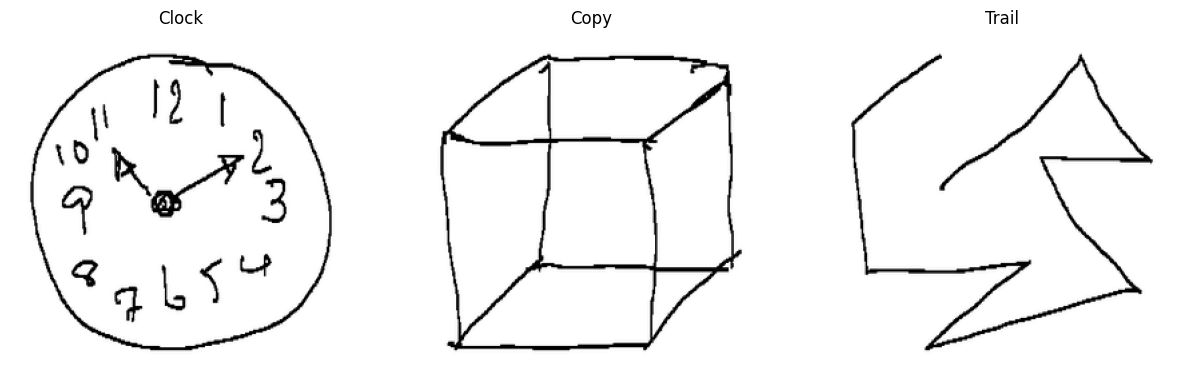

Label : 1
MoCA : 24.0
Train : 642 patients
Validation : 138 patients
Test : 138 patients

Class Weights
tensor([0.7055, 1.7166], device='cuda:0')

Batch Shapes
Clock : torch.Size([16, 3, 300, 300])
Copy  : torch.Size([16, 3, 300, 300])
Trail : torch.Size([16, 3, 300, 300])
Label : torch.Size([16])
Downloading: "https://download.pytorch.org/models/efficientnet_b3_rwightman-b3899882.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b3_rwightman-b3899882.pth


100%|██████████| 47.2M/47.2M [00:00<00:00, 92.0MB/s]


Model Summary
Backbone : efficientnet_b3
Trainable Parameters : 10,942,048
Total Parameters     : 13,132,202
Training Components Ready
Loss Function : FocalLoss
Optimizer     : AdamW
Scheduler     : ReduceLROnPlateau
EarlyStopping : Patience = 10
Training Started


  0%|          | 0/40 [00:00<?, ?it/s]

  0%|          | 0/9 [00:00<?, ?it/s]

...

Epoch 13/50 | Train Loss 0.1631 | Train Acc 0.5969 | Val Loss 0.2368 | Val Acc 0.8116 | Val AUC 0.8119 | LR 2.50e-05
EarlyStopping: 10/10

Early stopping activated.

Training Finished
Best Validation AUC : 0.8233
Loading Best Model


  0%|          | 0/9 [00:00<?, ?it/s]


Best Threshold = 0.47
Validation F1 = 0.6301


  0%|          | 0/9 [00:00<?, ?it/s]


TEST RESULTS
Threshold   : 0.47
Test Loss   : 0.2355
Accuracy    : 0.7609
Precision   : 0.6000
Recall      : 0.5250
Specificity : 0.8571
F1 Score    : 0.5600
ROC AUC     : 0.7316

Confusion Matrix
[[84 14]
 [19 21]]

Classification Report

              precision    recall  f1-score   support

      Normal       0.82      0.86      0.84        98
         MCI       0.60      0.53      0.56        40

    accuracy                           0.76       138
   macro avg       0.71      0.69      0.70       138
weighted avg       0.75      0.76      0.76       138


Metrics saved to
/content/drive/MyDrive/MCI_Results_efficientnet_b3/test_metrics.csv


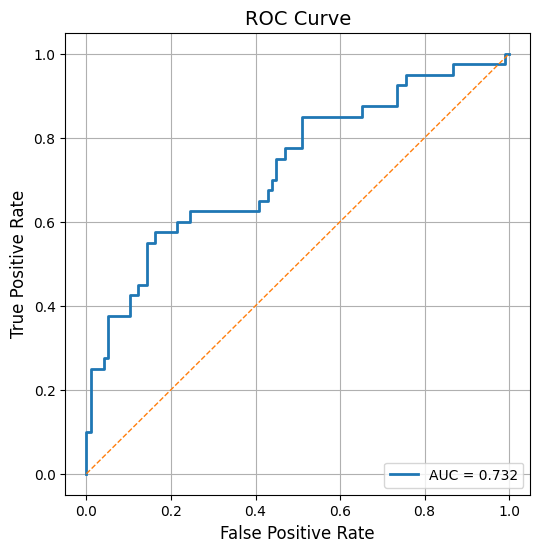

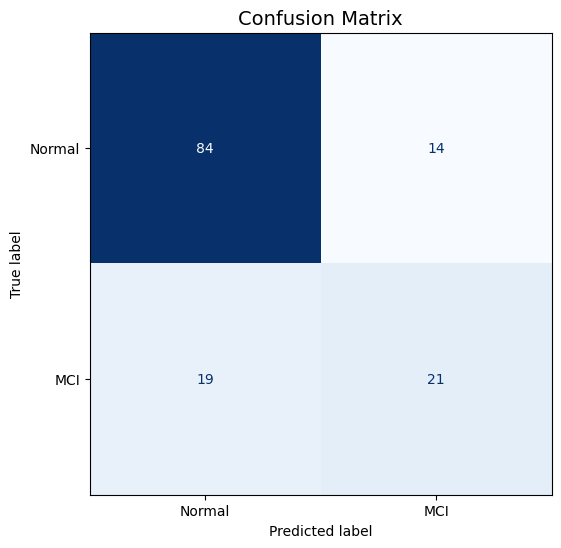

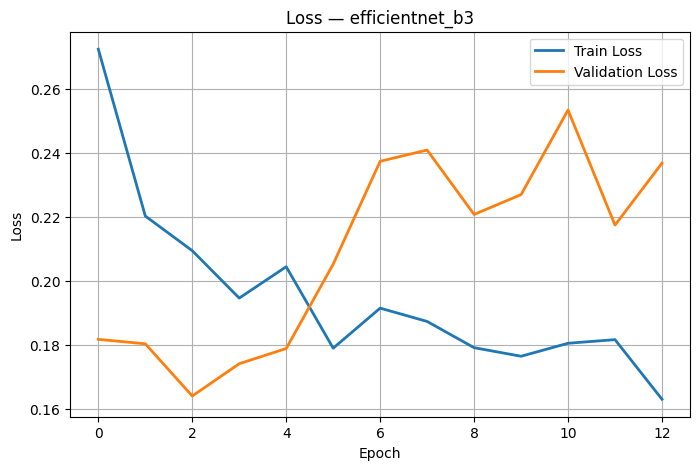

Results Saved
ROC Curve          : /content/drive/MyDrive/MCI_Results_efficientnet_b3/roc_curve.png
Confusion Matrix   : /content/drive/MyDrive/MCI_Results_efficientnet_b3/confusion_matrix.png
Predictions CSV    : /content/drive/MyDrive/MCI_Results_efficientnet_b3/test_predictions.csv
Loss Curve         : /content/drive/MyDrive/MCI_Results_efficientnet_b3/loss_curve.png
Metrics CSV        : /content/drive/MyDrive/MCI_Results_efficientnet_b3/test_metrics.csv


In [ ]:
# -----------------------------
# Standard libraries
# -----------------------------
import os, json, random, warnings, platform
import numpy as np
import pandas as pd
from PIL import Image

warnings.filterwarnings("ignore")

# -----------------------------
# PyTorch / TorchVision
# -----------------------------
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torch.cuda.amp import autocast, GradScaler

import torchvision
from torchvision import transforms
import torchvision.models as models

# -----------------------------
# Sklearn
# -----------------------------
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, classification_report,
    roc_curve, auc, ConfusionMatrixDisplay,
)
from sklearn.utils.class_weight import compute_class_weight

# -----------------------------
# Viz / progress
# -----------------------------
import matplotlib.pyplot as plt
from tqdm.auto import tqdm

# ==========================================================
# SEED / DEVICE
# ==========================================================

SEED = 42
random.seed(SEED); np.random.seed(SEED)
torch.manual_seed(SEED); torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("=" * 60)
print("Device :", DEVICE)
if DEVICE.type == "cuda":
    print("GPU :", torch.cuda.get_device_name(0))
print("=" * 60)

# ==========================================================
# PATHS
# ==========================================================

DATASET_ROOT = "/content/drive/MyDrive/MCI_dataset"
TRAIN_CSV = os.path.join(DATASET_ROOT, "split/train.csv")
VAL_CSV   = os.path.join(DATASET_ROOT, "split/val.csv")
TEST_CSV  = os.path.join(DATASET_ROOT, "split/test.csv")

# ==========================================================
# MODEL / TRAINING CONFIG — change BACKBONE for experiments
# ==========================================================

BACKBONE = "efficientnet_b3"      # "efficientnet_b3" or "densenet121"
OUTPUT_DIR = f"/content/drive/MyDrive/MCI_Results_{BACKBONE}"
os.makedirs(OUTPUT_DIR, exist_ok=True)
CHECKPOINT_PATH = os.path.join(OUTPUT_DIR, "best_model.pth")

NUM_CLASSES = 2
IMAGE_SIZE = 300 if BACKBONE == "efficientnet_b3" else 224
BATCH_SIZE = 16
NUM_WORKERS = 2
EPOCHS = 50
LEARNING_RATE = 1e-4
WEIGHT_DECAY = 1e-4
UNFREEZE_FRACTION = 0.30       # fraction of backbone conv-block stack to fine-tune
GRAD_CLIP_NORM = 1.0
EARLY_STOPPING_PATIENCE = 10
USE_AMP = torch.cuda.is_available()

print("\nConfiguration")
print("-" * 60)
print(f"Backbone        : {BACKBONE}")
print(f"Image Size      : {IMAGE_SIZE}")
print(f"Batch Size      : {BATCH_SIZE}")
print(f"Epochs          : {EPOCHS}")
print(f"Learning Rate   : {LEARNING_RATE}")
print(f"Weight Decay    : {WEIGHT_DECAY}")
print(f"Unfreeze Frac.  : {UNFREEZE_FRACTION}")
print(f"Mixed Precision : {USE_AMP}")
print("-" * 60)


def save_run_manifest():
    manifest = {
        "backbone": BACKBONE, "seed": SEED, "image_size": IMAGE_SIZE,
        "batch_size": BATCH_SIZE, "epochs": EPOCHS,
        "unfreeze_fraction": UNFREEZE_FRACTION,
        "learning_rate": LEARNING_RATE, "weight_decay": WEIGHT_DECAY,
        "grad_clip_norm": GRAD_CLIP_NORM,
        "torch_version": torch.__version__,
        "torchvision_version": torchvision.__version__,
        "python_version": platform.python_version(),
        "cuda_available": torch.cuda.is_available(),
        "gpu_name": torch.cuda.get_device_name(0) if torch.cuda.is_available() else None,
    }
    with open(os.path.join(OUTPUT_DIR, "run_manifest.json"), "w") as f:
        json.dump(manifest, f, indent=2)
    print("Run manifest saved to", os.path.join(OUTPUT_DIR, "run_manifest.json"))


save_run_manifest()

# ==========================================================
# DATASET
# ==========================================================

class MCIDataset(Dataset):
    def __init__(self, csv_file, transform=None):
        self.df = pd.read_csv(csv_file, dtype={"patient_id": str}).reset_index(drop=True)
        self.transform = transform
        print(f"{os.path.basename(csv_file)} : {len(self.df)} patients")

    def __len__(self):
        return len(self.df)

    def load_image(self, image_path):
        image = Image.open(image_path).convert("RGB")
        if self.transform is not None:
            image = self.transform(image)
        return image

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        return {
            "patient_id": row["patient_id"],
            "clock": self.load_image(row["clock_path"]),
            "copy": self.load_image(row["copy_path"]),
            "trail": self.load_image(row["trail_path"]),
            "label": torch.tensor(int(row["label"]), dtype=torch.long),
            "moca": float(row["MoCA_score"]),
        }


train_df = pd.read_csv(TRAIN_CSV)
val_df = pd.read_csv(VAL_CSV)
test_df = pd.read_csv(TEST_CSV)

print()
print("Train :", len(train_df))
print("Validation :", len(val_df))
print("Test :", len(test_df))
print()
print(train_df.head())

# ==========================================================
# TRANSFORMS
# NOTE: no RandomHorizontalFlip — clock numerals and trail
# direction are semantically meaningful and mirroring them
# would corrupt the diagnostic signal.
# ==========================================================

IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD = [0.229, 0.224, 0.225]

train_transform = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.RandomRotation(10),
    transforms.RandomAffine(degrees=0, translate=(0.05, 0.05), scale=(0.9, 1.1)),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(),
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
])

val_transform = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
])

train_dataset = MCIDataset(TRAIN_CSV, transform=train_transform)
val_dataset   = MCIDataset(VAL_CSV,   transform=val_transform)
test_dataset  = MCIDataset(TEST_CSV,  transform=val_transform)

# Sanity check — transformed sample should be a tensor
sample = train_dataset[0]
print()
print(sample["patient_id"], sample["label"], sample["moca"])
print(type(sample["clock"]), type(sample["copy"]), type(sample["trail"]))

# Preview raw (untransformed) images from a separate dataset instance
preview_dataset = MCIDataset(TRAIN_CSV, transform=None)
patient = preview_dataset[0]

plt.figure(figsize=(15, 5))
plt.subplot(1, 3, 1); plt.imshow(patient["clock"]); plt.title("Clock"); plt.axis("off")
plt.subplot(1, 3, 2); plt.imshow(patient["copy"]);  plt.title("Copy");  plt.axis("off")
plt.subplot(1, 3, 3); plt.imshow(patient["trail"]); plt.title("Trail"); plt.axis("off")
plt.show()
print("Label :", patient["label"].item())
print("MoCA :", patient["moca"])

# ==========================================================
# DATALOADERS
# drop_last=True on TRAIN ONLY: the classifier head has
# BatchNorm1d layers, which crash on a batch of size 1. A
# size-1 final batch happens whenever
# len(train_dataset) % BATCH_SIZE == 1 — silent otherwise.
# Val/test keep every sample since we want every prediction
# for correct metrics, and eval-mode BatchNorm uses running
# stats so a small last batch there is not a problem.
# ==========================================================

PIN_MEMORY = True

train_loader = DataLoader(
    train_dataset, batch_size=BATCH_SIZE, shuffle=True,
    num_workers=NUM_WORKERS, pin_memory=PIN_MEMORY,
    persistent_workers=(NUM_WORKERS > 0), drop_last=True,
)
val_loader = DataLoader(
    val_dataset, batch_size=BATCH_SIZE, shuffle=False,
    num_workers=NUM_WORKERS, pin_memory=PIN_MEMORY,
    persistent_workers=(NUM_WORKERS > 0),
)
test_loader = DataLoader(
    test_dataset, batch_size=BATCH_SIZE, shuffle=False,
    num_workers=NUM_WORKERS, pin_memory=PIN_MEMORY,
    persistent_workers=(NUM_WORKERS > 0),
)

print(f"Train : {len(train_dataset)} patients")
print(f"Validation : {len(val_dataset)} patients")
print(f"Test : {len(test_dataset)} patients")

class_weights = compute_class_weight(
    class_weight="balanced", classes=np.unique(train_df["label"]), y=train_df["label"]
)
class_weights = torch.tensor(class_weights, dtype=torch.float32, device=DEVICE)
print("\nClass Weights"); print(class_weights)

batch = next(iter(train_loader))
print("\nBatch Shapes")
print("Clock :", batch["clock"].shape)
print("Copy  :", batch["copy"].shape)
print("Trail :", batch["trail"].shape)
print("Label :", batch["label"].shape)

# ==========================================================
# MODEL
# ==========================================================

def build_backbone(name):
    if name.lower() == "efficientnet_b3":
        weights = models.EfficientNet_B3_Weights.IMAGENET1K_V1
        backbone = models.efficientnet_b3(weights=weights)
        feature_dim = backbone.classifier[1].in_features
        backbone.classifier = nn.Identity()
    elif name.lower() == "densenet121":
        weights = models.DenseNet121_Weights.IMAGENET1K_V1
        backbone = models.densenet121(weights=weights)
        feature_dim = backbone.classifier.in_features
        backbone.classifier = nn.Identity()
    else:
        raise ValueError("Unsupported backbone")
    return backbone, feature_dim


class MCIClassifier(nn.Module):

    def __init__(self, backbone_name="efficientnet_b3", num_classes=2,
                 unfreeze_fraction=0.30):
        super().__init__()

        self.backbone_name = backbone_name.lower()
        self.backbone, feature_dim = build_backbone(backbone_name)

        # Freeze everything first.
        for param in self.backbone.parameters():
            param.requires_grad = False

        # FIX: unfreeze the last `unfreeze_fraction` of the actual
        # conv-block stack under backbone.features — NOT
        # backbone.children(), which for EfficientNet/DenseNet is
        # only 2-3 top-level blocks (features/avgpool/classifier).
        # Using backbone.children() silently unfreezes only the
        # empty Identity() classifier and leaves every conv layer
        # frozen — i.e. no real fine-tuning happens at all.
        feature_children = list(self.backbone.features.children())
        n = len(feature_children)
        start = int(n * (1 - unfreeze_fraction))
        for child in feature_children[start:]:
            for param in child.parameters():
                param.requires_grad = True

        fusion_dim = feature_dim * 3
        self.classifier = nn.Sequential(
            nn.BatchNorm1d(fusion_dim), nn.Dropout(0.50),
            nn.Linear(fusion_dim, 512), nn.ReLU(inplace=True),
            nn.BatchNorm1d(512), nn.Dropout(0.40),
            nn.Linear(512, 128), nn.ReLU(inplace=True),
            nn.Dropout(0.30), nn.Linear(128, num_classes),
        )

    def forward(self, clock, copy, trail):
        # Calling self.backbone(x) directly is correct here: both
        # EfficientNet's and DenseNet's own forward() already do
        # pool -> flatten -> classifier(Identity) internally, so no
        # manual pooling step is needed (unlike scripts that call
        # backbone.features(x) directly, which skips that step).
        f1 = self.backbone(clock)
        f2 = self.backbone(copy)
        f3 = self.backbone(trail)
        fusion = torch.cat([f1, f2, f3], dim=1)
        return self.classifier(fusion)


model = MCIClassifier(BACKBONE, NUM_CLASSES, UNFREEZE_FRACTION).to(DEVICE)

trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
total = sum(p.numel() for p in model.parameters())
print("=" * 60)
print("Model Summary")
print("=" * 60)
print("Backbone :", BACKBONE)
print(f"Trainable Parameters : {trainable:,}")
print(f"Total Parameters     : {total:,}")
print("=" * 60)

# ==========================================================
# LOSS / OPTIMIZER / SCHEDULER
# ==========================================================

class FocalLoss(nn.Module):
    def __init__(self, alpha=None, gamma=2.0, reduction="mean"):
        super().__init__()
        self.alpha, self.gamma, self.reduction = alpha, gamma, reduction

    def forward(self, inputs, targets):
        ce_loss = nn.functional.cross_entropy(inputs, targets, weight=self.alpha, reduction="none")
        pt = torch.exp(-ce_loss)
        focal_loss = ((1 - pt) ** self.gamma) * ce_loss
        if self.reduction == "mean":
            return focal_loss.mean()
        elif self.reduction == "sum":
            return focal_loss.sum()
        return focal_loss


criterion = FocalLoss(alpha=class_weights, gamma=2.0)

optimizer = optim.AdamW(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY,
)

scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode="min", factor=0.5, patience=3)
scaler = GradScaler(enabled=USE_AMP)


class EarlyStopping:
    def __init__(self, patience=10, min_delta=0.0):
        self.patience, self.min_delta = patience, min_delta
        self.counter, self.best_loss, self.stop = 0, float("inf"), False

    def __call__(self, val_loss):
        if val_loss < self.best_loss - self.min_delta:
            self.best_loss, self.counter = val_loss, 0
        else:
            self.counter += 1
            print(f"EarlyStopping: {self.counter}/{self.patience}")
            if self.counter >= self.patience:
                self.stop = True


early_stopping = EarlyStopping(patience=EARLY_STOPPING_PATIENCE)
history = {"train_loss": [], "train_acc": [], "val_loss": [], "val_acc": [], "val_auc": [], "lr": []}

print("=" * 60)
print("Training Components Ready")
print("=" * 60)
print("Loss Function :", criterion.__class__.__name__)
print("Optimizer     : AdamW")
print("Scheduler     : ReduceLROnPlateau")
print("EarlyStopping : Patience =", early_stopping.patience)
print("=" * 60)

# ==========================================================
# TRAIN / VALIDATE
# ==========================================================

def train_one_epoch(model, loader):
    model.train()
    running_loss, running_correct, total = 0.0, 0, 0
    loop = tqdm(loader, leave=False)
    for batch in loop:
        clock = batch["clock"].to(DEVICE, non_blocking=True)
        copy = batch["copy"].to(DEVICE, non_blocking=True)
        trail = batch["trail"].to(DEVICE, non_blocking=True)
        labels = batch["label"].to(DEVICE)

        optimizer.zero_grad()
        with autocast(enabled=USE_AMP):
            outputs = model(clock, copy, trail)
            loss = criterion(outputs, labels)

        scaler.scale(loss).backward()
        # Grad clipping for stability — must unscale first when using AMP.
        scaler.unscale_(optimizer)
        torch.nn.utils.clip_grad_norm_(model.parameters(), GRAD_CLIP_NORM)
        scaler.step(optimizer)
        scaler.update()

        preds = outputs.argmax(dim=1)
        running_loss += loss.item() * labels.size(0)
        running_correct += (preds == labels).sum().item()
        total += labels.size(0)
        loop.set_postfix(loss=f"{loss.item():.4f}", acc=f"{100*running_correct/total:.2f}%")

    return running_loss / total, running_correct / total


def validate(model, loader):
    model.eval()
    running_loss, running_correct, total = 0.0, 0, 0
    y_true, y_prob = [], []
    with torch.no_grad():
        for batch in tqdm(loader, leave=False):
            clock = batch["clock"].to(DEVICE, non_blocking=True)
            copy = batch["copy"].to(DEVICE, non_blocking=True)
            trail = batch["trail"].to(DEVICE, non_blocking=True)
            labels = batch["label"].to(DEVICE)

            with autocast(enabled=USE_AMP):
                outputs = model(clock, copy, trail)
                loss = criterion(outputs, labels)

            probs = torch.softmax(outputs, dim=1)
            preds = outputs.argmax(dim=1)
            running_loss += loss.item() * labels.size(0)
            running_correct += (preds == labels).sum().item()
            total += labels.size(0)
            y_true.extend(labels.cpu().numpy())
            y_prob.extend(probs[:, 1].cpu().numpy())

    try:
        epoch_auc = roc_auc_score(y_true, y_prob)
    except Exception:
        epoch_auc = 0.5

    return running_loss / total, running_correct / total, epoch_auc


# ==========================================================
# TRAINING LOOP
# ==========================================================

print("=" * 70); print("Training Started"); print("=" * 70)
best_auc = 0.0

for epoch in range(EPOCHS):
    train_loss, train_acc = train_one_epoch(model, train_loader)
    val_loss, val_acc, val_auc = validate(model, val_loader)
    scheduler.step(val_loss)

    history["train_loss"].append(train_loss)
    history["train_acc"].append(train_acc)
    history["val_loss"].append(val_loss)
    history["val_acc"].append(val_acc)
    history["val_auc"].append(val_auc)
    history["lr"].append(optimizer.param_groups[0]["lr"])

    print(
        f"Epoch {epoch+1:02d}/{EPOCHS}"
        f" | Train Loss {train_loss:.4f}"
        f" | Train Acc {train_acc:.4f}"
        f" | Val Loss {val_loss:.4f}"
        f" | Val Acc {val_acc:.4f}"
        f" | Val AUC {val_auc:.4f}"
        f" | LR {optimizer.param_groups[0]['lr']:.2e}"
    )

    if val_auc > best_auc:
        best_auc = val_auc
        torch.save(model.state_dict(), CHECKPOINT_PATH)
        print("★★★★★ Best Model Updated ★★★★★")

    early_stopping(val_loss)
    if early_stopping.stop:
        print("\nEarly stopping activated.")
        break

print("\n" + "=" * 70)
print("Training Finished")
print("=" * 70)
print(f"Best Validation AUC : {best_auc:.4f}")

# ==========================================================
# TEST EVALUATION (threshold tuned on val)
# ==========================================================

print("=" * 60); print("Loading Best Model"); print("=" * 60)
model.load_state_dict(torch.load(CHECKPOINT_PATH))
model.eval()

val_probs, val_labels = [], []
with torch.no_grad():
    for batch in tqdm(val_loader):
        clock = batch["clock"].to(DEVICE)
        copy = batch["copy"].to(DEVICE)
        trail = batch["trail"].to(DEVICE)
        labels = batch["label"].cpu().numpy()
        outputs = model(clock, copy, trail)
        probs = torch.softmax(outputs, dim=1)[:, 1]
        val_probs.extend(probs.cpu().numpy())
        val_labels.extend(labels)

best_threshold, best_f1 = 0.50, 0
for t in np.arange(0.20, 0.81, 0.01):
    preds = (np.array(val_probs) >= t).astype(int)
    f1 = f1_score(val_labels, preds)
    if f1 > best_f1:
        best_f1, best_threshold = f1, t

print(f"\nBest Threshold = {best_threshold:.2f}")
print(f"Validation F1 = {best_f1:.4f}")

test_probs, test_preds, test_labels = [], [], []
running_loss, total = 0, 0
with torch.no_grad():
    for batch in tqdm(test_loader):
        clock = batch["clock"].to(DEVICE)
        copy = batch["copy"].to(DEVICE)
        trail = batch["trail"].to(DEVICE)
        labels = batch["label"].to(DEVICE)

        outputs = model(clock, copy, trail)
        loss = criterion(outputs, labels)
        probs = torch.softmax(outputs, dim=1)[:, 1]
        preds = (probs >= best_threshold).long()

        running_loss += loss.item() * labels.size(0)
        total += labels.size(0)
        test_probs.extend(probs.cpu().numpy())
        test_preds.extend(preds.cpu().numpy())
        test_labels.extend(labels.cpu().numpy())

test_loss = running_loss / total
accuracy = accuracy_score(test_labels, test_preds)
precision = precision_score(test_labels, test_preds)
recall = recall_score(test_labels, test_preds)
f1 = f1_score(test_labels, test_preds)
test_auc = roc_auc_score(test_labels, test_probs)
cm = confusion_matrix(test_labels, test_preds)
tn, fp, fn, tp = cm.ravel()
specificity = tn / (tn + fp)

print("\n" + "=" * 70)
print("TEST RESULTS")
print("=" * 70)
print(f"Threshold   : {best_threshold:.2f}")
print(f"Test Loss   : {test_loss:.4f}")
print(f"Accuracy    : {accuracy:.4f}")
print(f"Precision   : {precision:.4f}")
print(f"Recall      : {recall:.4f}")
print(f"Specificity : {specificity:.4f}")
print(f"F1 Score    : {f1:.4f}")
print(f"ROC AUC     : {test_auc:.4f}")
print("=" * 70)
print("\nConfusion Matrix"); print(cm)
print("\nClassification Report\n")
print(classification_report(test_labels, test_preds, target_names=["Normal", "MCI"]))

metrics = pd.DataFrame({
    "Accuracy": [accuracy], "Precision": [precision], "Recall": [recall],
    "Specificity": [specificity], "F1": [f1], "AUC": [test_auc],
    "Threshold": [best_threshold],
})
metrics_path = os.path.join(OUTPUT_DIR, "test_metrics.csv")
metrics.to_csv(metrics_path, index=False)
print("\nMetrics saved to"); print(metrics_path)

# ==========================================================
# ROC CURVE, CONFUSION MATRIX, PREDICTIONS
# ==========================================================

fpr, tpr, _ = roc_curve(test_labels, test_probs)
roc_auc_val = auc(fpr, tpr)

plt.figure(figsize=(6, 6))
plt.plot(fpr, tpr, lw=2, label=f"AUC = {roc_auc_val:.3f}")
plt.plot([0, 1], [0, 1], linestyle="--", linewidth=1)
plt.xlabel("False Positive Rate", fontsize=12)
plt.ylabel("True Positive Rate", fontsize=12)
plt.title("ROC Curve", fontsize=14)
plt.legend(loc="lower right")
plt.grid(True)
roc_path = os.path.join(OUTPUT_DIR, "roc_curve.png")
plt.savefig(roc_path, dpi=300, bbox_inches="tight")
plt.show()

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Normal", "MCI"])
fig, ax = plt.subplots(figsize=(6, 6))
disp.plot(cmap="Blues", ax=ax, colorbar=False, values_format="d")
plt.title("Confusion Matrix", fontsize=14)
cm_path = os.path.join(OUTPUT_DIR, "confusion_matrix.png")
plt.savefig(cm_path, dpi=300, bbox_inches="tight")
plt.show()

predictions = pd.DataFrame({
    "True_Label": test_labels, "Predicted_Label": test_preds, "Probability_MCI": test_probs
})
prediction_path = os.path.join(OUTPUT_DIR, "test_predictions.csv")
predictions.to_csv(prediction_path, index=False)

# Loss/accuracy curves — useful for spotting overfitting at a glance
plt.figure(figsize=(8, 5))
plt.plot(history["train_loss"], label="Train Loss", linewidth=2)
plt.plot(history["val_loss"], label="Validation Loss", linewidth=2)
plt.xlabel("Epoch"); plt.ylabel("Loss"); plt.title(f"Loss — {BACKBONE}")
plt.legend(); plt.grid(True)
loss_curve_path = os.path.join(OUTPUT_DIR, "loss_curve.png")
plt.savefig(loss_curve_path, dpi=300, bbox_inches="tight")
plt.show()

print("=" * 60)
print("Results Saved")
print("=" * 60)
print("ROC Curve          :", roc_path)
print("Confusion Matrix   :", cm_path)
print("Predictions CSV    :", prediction_path)
print("Loss Curve         :", loss_curve_path)
print("Metrics CSV        :", metrics_path)

VitB16

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Device : cuda
GPU : Tesla T4

Configuration
------------------------------------------------------------
Backbone        : vit_b16
Image Size      : 224
Batch Size      : 16
Epochs          : 50
Learning Rate   : 0.0001
Weight Decay    : 0.0001
Unfreeze Frac.  : 0.3
Mixed Precision : True
------------------------------------------------------------
Run manifest saved to /content/drive/MyDrive/MCI_Results_vit_b16/run_manifest.json

Train : 642
Validation : 138
Test : 138

            patient_id  MoCA_score  label label_name  \
0   741365287116041472          24      1        MCI   
1   337140389762916207          30      0     Normal   
2  6386301594803982624          27      0     Normal   
3  6211790656715700606          29      0     Normal   
4   440601492270586615          30      0     Normal   

                                          clock_path clock

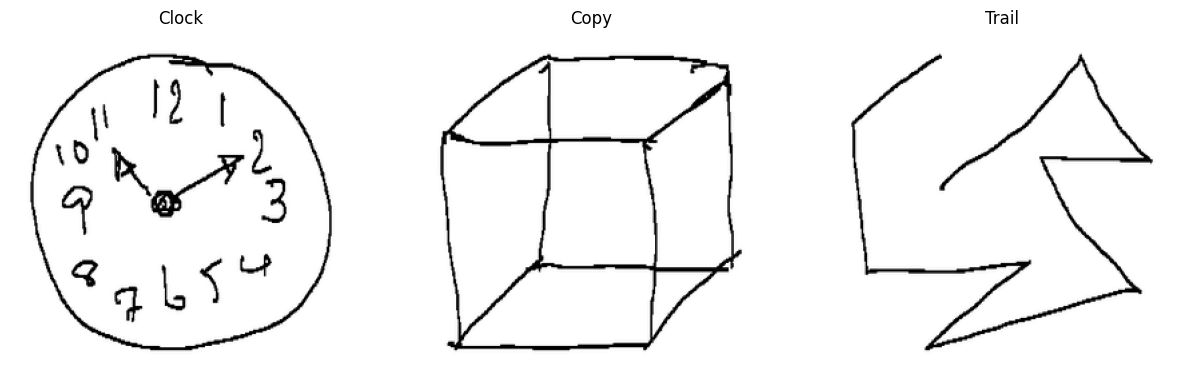

Label : 1
MoCA : 24.0
Train : 642 patients
Validation : 138 patients
Test : 138 patients

Class Weights
tensor([0.7055, 1.7166], device='cuda:0')

Batch Shapes
Clock : torch.Size([16, 3, 224, 224])
Copy  : torch.Size([16, 3, 224, 224])
Trail : torch.Size([16, 3, 224, 224])
Label : torch.Size([16])
Downloading: "https://download.pytorch.org/models/vit_b_16-c867db91.pth" to /root/.cache/torch/hub/checkpoints/vit_b_16-c867db91.pth


100%|██████████| 330M/330M [00:01<00:00, 176MB/s]


Model Summary
Backbone : vit_b16
Trainable Parameters : 29,604,738
Total Parameters     : 87,050,370
Training Components Ready
Loss Function : FocalLoss
Optimizer     : AdamW
Scheduler     : ReduceLROnPlateau
EarlyStopping : Patience = 10
Training Started


  0%|          | 0/40 [00:00<?, ?it/s]

  0%|          | 0/9 [00:00<?, ?it/s]

...

Epoch 18/50 | Train Loss 0.1388 | Train Acc 0.7234 | Val Loss 0.1980 | Val Acc 0.6667 | Val AUC 0.7219 | LR 1.25e-05
EarlyStopping: 10/10

Early stopping activated.

Training Finished
Best Validation AUC : 0.7491
Loading Best Model


  0%|          | 0/9 [00:00<?, ?it/s]


Best Threshold = 0.56
Validation F1 = 0.5797


  0%|          | 0/9 [00:00<?, ?it/s]


TEST RESULTS
Threshold   : 0.56
Test Loss   : 0.2164
Accuracy    : 0.7681
Precision   : 0.6667
Recall      : 0.4000
Specificity : 0.9184
F1 Score    : 0.5000
ROC AUC     : 0.7365

Confusion Matrix
[[90  8]
 [24 16]]

Classification Report

              precision    recall  f1-score   support

      Normal       0.79      0.92      0.85        98
         MCI       0.67      0.40      0.50        40

    accuracy                           0.77       138
   macro avg       0.73      0.66      0.67       138
weighted avg       0.75      0.77      0.75       138


Metrics saved to
/content/drive/MyDrive/MCI_Results_vit_b16/test_metrics.csv


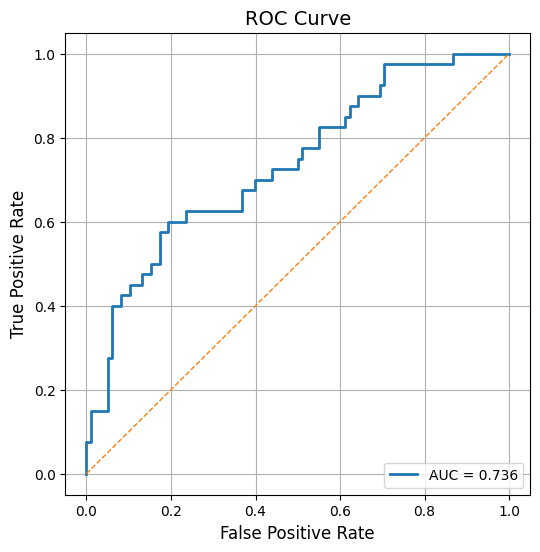

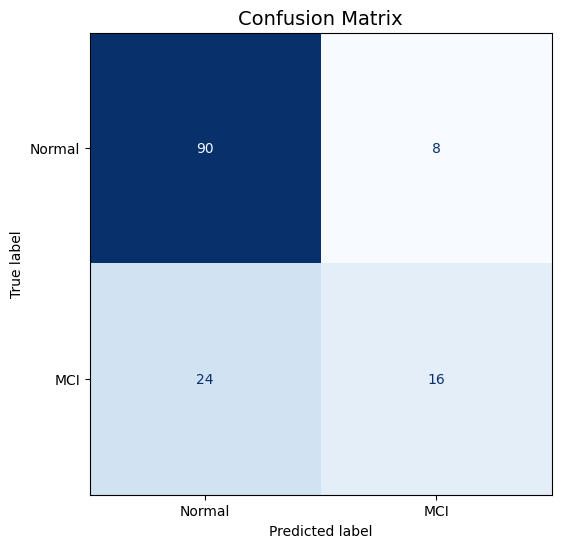

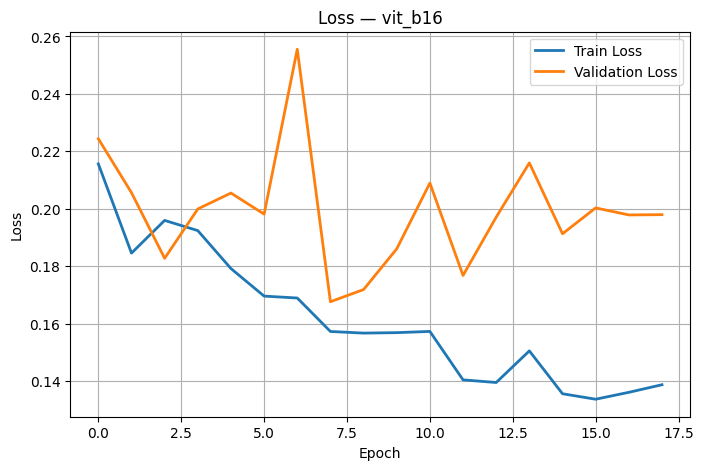

Results Saved
ROC Curve          : /content/drive/MyDrive/MCI_Results_vit_b16/roc_curve.png
Confusion Matrix   : /content/drive/MyDrive/MCI_Results_vit_b16/confusion_matrix.png
Predictions CSV    : /content/drive/MyDrive/MCI_Results_vit_b16/test_predictions.csv
Loss Curve         : /content/drive/MyDrive/MCI_Results_vit_b16/loss_curve.png
Metrics CSV        : /content/drive/MyDrive/MCI_Results_vit_b16/test_metrics.csv


In [ ]:
# -----------------------------
# Standard libraries
# -----------------------------
import os, json, random, warnings, platform
import numpy as np
import pandas as pd
from PIL import Image

warnings.filterwarnings("ignore")

# -----------------------------
# PyTorch / TorchVision
# -----------------------------
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torch.cuda.amp import autocast, GradScaler

import torchvision
from torchvision import transforms
import torchvision.models as models

# -----------------------------
# Sklearn
# -----------------------------
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, classification_report,
    roc_curve, auc, ConfusionMatrixDisplay,
)
from sklearn.utils.class_weight import compute_class_weight

# -----------------------------
# Viz / progress
# -----------------------------
import matplotlib.pyplot as plt
from tqdm.auto import tqdm

# ==========================================================
# SEED / DEVICE
# ==========================================================

SEED = 42
random.seed(SEED); np.random.seed(SEED)
torch.manual_seed(SEED); torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("=" * 60)
print("Device :", DEVICE)
if DEVICE.type == "cuda":
    print("GPU :", torch.cuda.get_device_name(0))
print("=" * 60)

# ==========================================================
# PATHS
# ==========================================================

DATASET_ROOT = "/content/drive/MyDrive/MCI_dataset"
TRAIN_CSV = os.path.join(DATASET_ROOT, "split/train.csv")
VAL_CSV   = os.path.join(DATASET_ROOT, "split/val.csv")
TEST_CSV  = os.path.join(DATASET_ROOT, "split/test.csv")

# ==========================================================
# MODEL / TRAINING CONFIG — change BACKBONE for experiments
# ==========================================================

BACKBONE = "vit_b16"          # "efficientnet_b3", "densenet121", or "vit_b16"
OUTPUT_DIR = f"/content/drive/MyDrive/MCI_Results_{BACKBONE}"
os.makedirs(OUTPUT_DIR, exist_ok=True)
CHECKPOINT_PATH = os.path.join(OUTPUT_DIR, "best_model.pth")

NUM_CLASSES = 2
IMAGE_SIZE = 300 if BACKBONE == "efficientnet_b3" else 224
BATCH_SIZE = 16
NUM_WORKERS = 2
EPOCHS = 50
LEARNING_RATE = 1e-4
WEIGHT_DECAY = 1e-4
UNFREEZE_FRACTION = 0.30       # fraction of backbone conv-block stack to fine-tune
GRAD_CLIP_NORM = 1.0
EARLY_STOPPING_PATIENCE = 10
USE_AMP = torch.cuda.is_available()

print("\nConfiguration")
print("-" * 60)
print(f"Backbone        : {BACKBONE}")
print(f"Image Size      : {IMAGE_SIZE}")
print(f"Batch Size      : {BATCH_SIZE}")
print(f"Epochs          : {EPOCHS}")
print(f"Learning Rate   : {LEARNING_RATE}")
print(f"Weight Decay    : {WEIGHT_DECAY}")
print(f"Unfreeze Frac.  : {UNFREEZE_FRACTION}")
print(f"Mixed Precision : {USE_AMP}")
print("-" * 60)


def save_run_manifest():
    manifest = {
        "backbone": BACKBONE, "seed": SEED, "image_size": IMAGE_SIZE,
        "batch_size": BATCH_SIZE, "epochs": EPOCHS,
        "unfreeze_fraction": UNFREEZE_FRACTION,
        "learning_rate": LEARNING_RATE, "weight_decay": WEIGHT_DECAY,
        "grad_clip_norm": GRAD_CLIP_NORM,
        "torch_version": torch.__version__,
        "torchvision_version": torchvision.__version__,
        "python_version": platform.python_version(),
        "cuda_available": torch.cuda.is_available(),
        "gpu_name": torch.cuda.get_device_name(0) if torch.cuda.is_available() else None,
    }
    with open(os.path.join(OUTPUT_DIR, "run_manifest.json"), "w") as f:
        json.dump(manifest, f, indent=2)
    print("Run manifest saved to", os.path.join(OUTPUT_DIR, "run_manifest.json"))


save_run_manifest()

# ==========================================================
# DATASET
# ==========================================================

class MCIDataset(Dataset):
    def __init__(self, csv_file, transform=None):
        self.df = pd.read_csv(csv_file, dtype={"patient_id": str}).reset_index(drop=True)
        self.transform = transform
        print(f"{os.path.basename(csv_file)} : {len(self.df)} patients")

    def __len__(self):
        return len(self.df)

    def load_image(self, image_path):
        image = Image.open(image_path).convert("RGB")
        if self.transform is not None:
            image = self.transform(image)
        return image

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        return {
            "patient_id": row["patient_id"],
            "clock": self.load_image(row["clock_path"]),
            "copy": self.load_image(row["copy_path"]),
            "trail": self.load_image(row["trail_path"]),
            "label": torch.tensor(int(row["label"]), dtype=torch.long),
            "moca": float(row["MoCA_score"]),
        }


train_df = pd.read_csv(TRAIN_CSV)
val_df = pd.read_csv(VAL_CSV)
test_df = pd.read_csv(TEST_CSV)

print()
print("Train :", len(train_df))
print("Validation :", len(val_df))
print("Test :", len(test_df))
print()
print(train_df.head())

# ==========================================================
# TRANSFORMS
# NOTE: no RandomHorizontalFlip — clock numerals and trail
# direction are semantically meaningful and mirroring them
# would corrupt the diagnostic signal.
# ==========================================================

IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD = [0.229, 0.224, 0.225]

train_transform = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.RandomRotation(10),
    transforms.RandomAffine(degrees=0, translate=(0.05, 0.05), scale=(0.9, 1.1)),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(),
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
])

val_transform = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
])

train_dataset = MCIDataset(TRAIN_CSV, transform=train_transform)
val_dataset   = MCIDataset(VAL_CSV,   transform=val_transform)
test_dataset  = MCIDataset(TEST_CSV,  transform=val_transform)

# Sanity check — transformed sample should be a tensor
sample = train_dataset[0]
print()
print(sample["patient_id"], sample["label"], sample["moca"])
print(type(sample["clock"]), type(sample["copy"]), type(sample["trail"]))

# Preview raw (untransformed) images from a separate dataset instance
preview_dataset = MCIDataset(TRAIN_CSV, transform=None)
patient = preview_dataset[0]

plt.figure(figsize=(15, 5))
plt.subplot(1, 3, 1); plt.imshow(patient["clock"]); plt.title("Clock"); plt.axis("off")
plt.subplot(1, 3, 2); plt.imshow(patient["copy"]);  plt.title("Copy");  plt.axis("off")
plt.subplot(1, 3, 3); plt.imshow(patient["trail"]); plt.title("Trail"); plt.axis("off")
plt.show()
print("Label :", patient["label"].item())
print("MoCA :", patient["moca"])

# ==========================================================
# DATALOADERS
# drop_last=True on TRAIN ONLY: the classifier head has
# BatchNorm1d layers, which crash on a batch of size 1. A
# size-1 final batch happens whenever
# len(train_dataset) % BATCH_SIZE == 1 — silent otherwise.
# Val/test keep every sample since we want every prediction
# for correct metrics, and eval-mode BatchNorm uses running
# stats so a small last batch there is not a problem.
# ==========================================================

PIN_MEMORY = True

train_loader = DataLoader(
    train_dataset, batch_size=BATCH_SIZE, shuffle=True,
    num_workers=NUM_WORKERS, pin_memory=PIN_MEMORY,
    persistent_workers=(NUM_WORKERS > 0), drop_last=True,
)
val_loader = DataLoader(
    val_dataset, batch_size=BATCH_SIZE, shuffle=False,
    num_workers=NUM_WORKERS, pin_memory=PIN_MEMORY,
    persistent_workers=(NUM_WORKERS > 0),
)
test_loader = DataLoader(
    test_dataset, batch_size=BATCH_SIZE, shuffle=False,
    num_workers=NUM_WORKERS, pin_memory=PIN_MEMORY,
    persistent_workers=(NUM_WORKERS > 0),
)

print(f"Train : {len(train_dataset)} patients")
print(f"Validation : {len(val_dataset)} patients")
print(f"Test : {len(test_dataset)} patients")

class_weights = compute_class_weight(
    class_weight="balanced", classes=np.unique(train_df["label"]), y=train_df["label"]
)
class_weights = torch.tensor(class_weights, dtype=torch.float32, device=DEVICE)
print("\nClass Weights"); print(class_weights)

batch = next(iter(train_loader))
print("\nBatch Shapes")
print("Clock :", batch["clock"].shape)
print("Copy  :", batch["copy"].shape)
print("Trail :", batch["trail"].shape)
print("Label :", batch["label"].shape)

# ==========================================================
# MODEL
# ==========================================================

def build_backbone(name):
    if name.lower() == "efficientnet_b3":
        weights = models.EfficientNet_B3_Weights.IMAGENET1K_V1
        backbone = models.efficientnet_b3(weights=weights)
        feature_dim = backbone.classifier[1].in_features
        backbone.classifier = nn.Identity()
    elif name.lower() == "densenet121":
        weights = models.DenseNet121_Weights.IMAGENET1K_V1
        backbone = models.densenet121(weights=weights)
        feature_dim = backbone.classifier.in_features
        backbone.classifier = nn.Identity()
    elif name.lower() == "vit_b16":
        weights = models.ViT_B_16_Weights.IMAGENET1K_V1
        backbone = models.vit_b_16(weights=weights)
        feature_dim = backbone.heads.head.in_features   # 768 for ViT-B/16
        backbone.heads.head = nn.Identity()
    else:
        raise ValueError("Unsupported backbone")
    return backbone, feature_dim


class MCIClassifier(nn.Module):

    def __init__(self, backbone_name="efficientnet_b3", num_classes=2,
                 unfreeze_fraction=0.30):
        super().__init__()

        self.backbone_name = backbone_name.lower()
        self.backbone, feature_dim = build_backbone(backbone_name)

        # Freeze everything first.
        for param in self.backbone.parameters():
            param.requires_grad = False

        # FIX: unfreeze the last `unfreeze_fraction` of the actual
        # block stack for this architecture — NOT backbone.children(),
        # which for EfficientNet/DenseNet is only 2-3 top-level blocks
        # (features/avgpool/classifier), and for ViT is also only a
        # handful of top-level modules (conv_proj/encoder/heads).
        # Using backbone.children() silently unfreezes only the empty
        # Identity() head and leaves every real layer frozen — i.e.
        # no fine-tuning happens at all.
        if self.backbone_name in ("densenet121", "efficientnet_b3"):
            block_children = list(self.backbone.features.children())
        elif self.backbone_name == "vit_b16":
            # ViT has no conv "features" stack — its 12 transformer
            # encoder blocks live at backbone.encoder.layers.
            block_children = list(self.backbone.encoder.layers.children())
        else:
            raise ValueError("Unsupported backbone")

        n = len(block_children)
        start = int(n * (1 - unfreeze_fraction))
        for child in block_children[start:]:
            for param in child.parameters():
                param.requires_grad = True

        # For ViT, also unfreeze the final encoder LayerNorm whenever
        # any encoder layers are trainable — leaving it frozen while
        # the layers feeding it are being fine-tuned tends to hurt
        # training stability.
        if self.backbone_name == "vit_b16" and unfreeze_fraction > 0:
            for param in self.backbone.encoder.ln.parameters():
                param.requires_grad = True

        fusion_dim = feature_dim * 3
        self.classifier = nn.Sequential(
            nn.BatchNorm1d(fusion_dim), nn.Dropout(0.50),
            nn.Linear(fusion_dim, 512), nn.ReLU(inplace=True),
            nn.BatchNorm1d(512), nn.Dropout(0.40),
            nn.Linear(512, 128), nn.ReLU(inplace=True),
            nn.Dropout(0.30), nn.Linear(128, num_classes),
        )

    def forward(self, clock, copy, trail):
        # Calling self.backbone(x) directly is correct here: both
        # EfficientNet's and DenseNet's own forward() already do
        # pool -> flatten -> classifier(Identity) internally, so no
        # manual pooling step is needed (unlike scripts that call
        # backbone.features(x) directly, which skips that step).
        f1 = self.backbone(clock)
        f2 = self.backbone(copy)
        f3 = self.backbone(trail)
        fusion = torch.cat([f1, f2, f3], dim=1)
        return self.classifier(fusion)


model = MCIClassifier(BACKBONE, NUM_CLASSES, UNFREEZE_FRACTION).to(DEVICE)

trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
total = sum(p.numel() for p in model.parameters())
print("=" * 60)
print("Model Summary")
print("=" * 60)
print("Backbone :", BACKBONE)
print(f"Trainable Parameters : {trainable:,}")
print(f"Total Parameters     : {total:,}")
print("=" * 60)

# ==========================================================
# LOSS / OPTIMIZER / SCHEDULER
# ==========================================================

class FocalLoss(nn.Module):
    def __init__(self, alpha=None, gamma=2.0, reduction="mean"):
        super().__init__()
        self.alpha, self.gamma, self.reduction = alpha, gamma, reduction

    def forward(self, inputs, targets):
        ce_loss = nn.functional.cross_entropy(inputs, targets, weight=self.alpha, reduction="none")
        pt = torch.exp(-ce_loss)
        focal_loss = ((1 - pt) ** self.gamma) * ce_loss
        if self.reduction == "mean":
            return focal_loss.mean()
        elif self.reduction == "sum":
            return focal_loss.sum()
        return focal_loss


criterion = FocalLoss(alpha=class_weights, gamma=2.0)

optimizer = optim.AdamW(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY,
)

scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode="min", factor=0.5, patience=3)
scaler = GradScaler(enabled=USE_AMP)


class EarlyStopping:
    def __init__(self, patience=10, min_delta=0.0):
        self.patience, self.min_delta = patience, min_delta
        self.counter, self.best_loss, self.stop = 0, float("inf"), False

    def __call__(self, val_loss):
        if val_loss < self.best_loss - self.min_delta:
            self.best_loss, self.counter = val_loss, 0
        else:
            self.counter += 1
            print(f"EarlyStopping: {self.counter}/{self.patience}")
            if self.counter >= self.patience:
                self.stop = True


early_stopping = EarlyStopping(patience=EARLY_STOPPING_PATIENCE)
history = {"train_loss": [], "train_acc": [], "val_loss": [], "val_acc": [], "val_auc": [], "lr": []}

print("=" * 60)
print("Training Components Ready")
print("=" * 60)
print("Loss Function :", criterion.__class__.__name__)
print("Optimizer     : AdamW")
print("Scheduler     : ReduceLROnPlateau")
print("EarlyStopping : Patience =", early_stopping.patience)
print("=" * 60)

# ==========================================================
# TRAIN / VALIDATE
# ==========================================================

def train_one_epoch(model, loader):
    model.train()
    running_loss, running_correct, total = 0.0, 0, 0
    loop = tqdm(loader, leave=False)
    for batch in loop:
        clock = batch["clock"].to(DEVICE, non_blocking=True)
        copy = batch["copy"].to(DEVICE, non_blocking=True)
        trail = batch["trail"].to(DEVICE, non_blocking=True)
        labels = batch["label"].to(DEVICE)

        optimizer.zero_grad()
        with autocast(enabled=USE_AMP):
            outputs = model(clock, copy, trail)
            loss = criterion(outputs, labels)

        scaler.scale(loss).backward()
        # Grad clipping for stability — must unscale first when using AMP.
        scaler.unscale_(optimizer)
        torch.nn.utils.clip_grad_norm_(model.parameters(), GRAD_CLIP_NORM)
        scaler.step(optimizer)
        scaler.update()

        preds = outputs.argmax(dim=1)
        running_loss += loss.item() * labels.size(0)
        running_correct += (preds == labels).sum().item()
        total += labels.size(0)
        loop.set_postfix(loss=f"{loss.item():.4f}", acc=f"{100*running_correct/total:.2f}%")

    return running_loss / total, running_correct / total


def validate(model, loader):
    model.eval()
    running_loss, running_correct, total = 0.0, 0, 0
    y_true, y_prob = [], []
    with torch.no_grad():
        for batch in tqdm(loader, leave=False):
            clock = batch["clock"].to(DEVICE, non_blocking=True)
            copy = batch["copy"].to(DEVICE, non_blocking=True)
            trail = batch["trail"].to(DEVICE, non_blocking=True)
            labels = batch["label"].to(DEVICE)

            with autocast(enabled=USE_AMP):
                outputs = model(clock, copy, trail)
                loss = criterion(outputs, labels)

            probs = torch.softmax(outputs, dim=1)
            preds = outputs.argmax(dim=1)
            running_loss += loss.item() * labels.size(0)
            running_correct += (preds == labels).sum().item()
            total += labels.size(0)
            y_true.extend(labels.cpu().numpy())
            y_prob.extend(probs[:, 1].cpu().numpy())

    try:
        epoch_auc = roc_auc_score(y_true, y_prob)
    except Exception:
        epoch_auc = 0.5

    return running_loss / total, running_correct / total, epoch_auc


# ==========================================================
# TRAINING LOOP
# ==========================================================

print("=" * 70); print("Training Started"); print("=" * 70)
best_auc = 0.0

for epoch in range(EPOCHS):
    train_loss, train_acc = train_one_epoch(model, train_loader)
    val_loss, val_acc, val_auc = validate(model, val_loader)
    scheduler.step(val_loss)

    history["train_loss"].append(train_loss)
    history["train_acc"].append(train_acc)
    history["val_loss"].append(val_loss)
    history["val_acc"].append(val_acc)
    history["val_auc"].append(val_auc)
    history["lr"].append(optimizer.param_groups[0]["lr"])

    print(
        f"Epoch {epoch+1:02d}/{EPOCHS}"
        f" | Train Loss {train_loss:.4f}"
        f" | Train Acc {train_acc:.4f}"
        f" | Val Loss {val_loss:.4f}"
        f" | Val Acc {val_acc:.4f}"
        f" | Val AUC {val_auc:.4f}"
        f" | LR {optimizer.param_groups[0]['lr']:.2e}"
    )

    if val_auc > best_auc:
        best_auc = val_auc
        torch.save(model.state_dict(), CHECKPOINT_PATH)
        print("★★★★★ Best Model Updated ★★★★★")

    early_stopping(val_loss)
    if early_stopping.stop:
        print("\nEarly stopping activated.")
        break

print("\n" + "=" * 70)
print("Training Finished")
print("=" * 70)
print(f"Best Validation AUC : {best_auc:.4f}")

# ==========================================================
# TEST EVALUATION (threshold tuned on val)
# ==========================================================

print("=" * 60); print("Loading Best Model"); print("=" * 60)
model.load_state_dict(torch.load(CHECKPOINT_PATH))
model.eval()

val_probs, val_labels = [], []
with torch.no_grad():
    for batch in tqdm(val_loader):
        clock = batch["clock"].to(DEVICE)
        copy = batch["copy"].to(DEVICE)
        trail = batch["trail"].to(DEVICE)
        labels = batch["label"].cpu().numpy()
        outputs = model(clock, copy, trail)
        probs = torch.softmax(outputs, dim=1)[:, 1]
        val_probs.extend(probs.cpu().numpy())
        val_labels.extend(labels)

best_threshold, best_f1 = 0.50, 0
for t in np.arange(0.20, 0.81, 0.01):
    preds = (np.array(val_probs) >= t).astype(int)
    f1 = f1_score(val_labels, preds)
    if f1 > best_f1:
        best_f1, best_threshold = f1, t

print(f"\nBest Threshold = {best_threshold:.2f}")
print(f"Validation F1 = {best_f1:.4f}")

test_probs, test_preds, test_labels = [], [], []
running_loss, total = 0, 0
with torch.no_grad():
    for batch in tqdm(test_loader):
        clock = batch["clock"].to(DEVICE)
        copy = batch["copy"].to(DEVICE)
        trail = batch["trail"].to(DEVICE)
        labels = batch["label"].to(DEVICE)

        outputs = model(clock, copy, trail)
        loss = criterion(outputs, labels)
        probs = torch.softmax(outputs, dim=1)[:, 1]
        preds = (probs >= best_threshold).long()

        running_loss += loss.item() * labels.size(0)
        total += labels.size(0)
        test_probs.extend(probs.cpu().numpy())
        test_preds.extend(preds.cpu().numpy())
        test_labels.extend(labels.cpu().numpy())

test_loss = running_loss / total
accuracy = accuracy_score(test_labels, test_preds)
precision = precision_score(test_labels, test_preds)
recall = recall_score(test_labels, test_preds)
f1 = f1_score(test_labels, test_preds)
test_auc = roc_auc_score(test_labels, test_probs)
cm = confusion_matrix(test_labels, test_preds)
tn, fp, fn, tp = cm.ravel()
specificity = tn / (tn + fp)

print("\n" + "=" * 70)
print("TEST RESULTS")
print("=" * 70)
print(f"Threshold   : {best_threshold:.2f}")
print(f"Test Loss   : {test_loss:.4f}")
print(f"Accuracy    : {accuracy:.4f}")
print(f"Precision   : {precision:.4f}")
print(f"Recall      : {recall:.4f}")
print(f"Specificity : {specificity:.4f}")
print(f"F1 Score    : {f1:.4f}")
print(f"ROC AUC     : {test_auc:.4f}")
print("=" * 70)
print("\nConfusion Matrix"); print(cm)
print("\nClassification Report\n")
print(classification_report(test_labels, test_preds, target_names=["Normal", "MCI"]))

metrics = pd.DataFrame({
    "Accuracy": [accuracy], "Precision": [precision], "Recall": [recall],
    "Specificity": [specificity], "F1": [f1], "AUC": [test_auc],
    "Threshold": [best_threshold],
})
metrics_path = os.path.join(OUTPUT_DIR, "test_metrics.csv")
metrics.to_csv(metrics_path, index=False)
print("\nMetrics saved to"); print(metrics_path)

# ==========================================================
# ROC CURVE, CONFUSION MATRIX, PREDICTIONS
# ==========================================================

fpr, tpr, _ = roc_curve(test_labels, test_probs)
roc_auc_val = auc(fpr, tpr)

plt.figure(figsize=(6, 6))
plt.plot(fpr, tpr, lw=2, label=f"AUC = {roc_auc_val:.3f}")
plt.plot([0, 1], [0, 1], linestyle="--", linewidth=1)
plt.xlabel("False Positive Rate", fontsize=12)
plt.ylabel("True Positive Rate", fontsize=12)
plt.title("ROC Curve", fontsize=14)
plt.legend(loc="lower right")
plt.grid(True)
roc_path = os.path.join(OUTPUT_DIR, "roc_curve.png")
plt.savefig(roc_path, dpi=300, bbox_inches="tight")
plt.show()

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Normal", "MCI"])
fig, ax = plt.subplots(figsize=(6, 6))
disp.plot(cmap="Blues", ax=ax, colorbar=False, values_format="d")
plt.title("Confusion Matrix", fontsize=14)
cm_path = os.path.join(OUTPUT_DIR, "confusion_matrix.png")
plt.savefig(cm_path, dpi=300, bbox_inches="tight")
plt.show()

predictions = pd.DataFrame({
    "True_Label": test_labels, "Predicted_Label": test_preds, "Probability_MCI": test_probs
})
prediction_path = os.path.join(OUTPUT_DIR, "test_predictions.csv")
predictions.to_csv(prediction_path, index=False)

# Loss/accuracy curves — useful for spotting overfitting at a glance
plt.figure(figsize=(8, 5))
plt.plot(history["train_loss"], label="Train Loss", linewidth=2)
plt.plot(history["val_loss"], label="Validation Loss", linewidth=2)
plt.xlabel("Epoch"); plt.ylabel("Loss"); plt.title(f"Loss — {BACKBONE}")
plt.legend(); plt.grid(True)
loss_curve_path = os.path.join(OUTPUT_DIR, "loss_curve.png")
plt.savefig(loss_curve_path, dpi=300, bbox_inches="tight")
plt.show()

print("=" * 60)
print("Results Saved")
print("=" * 60)
print("ROC Curve          :", roc_path)
print("Confusion Matrix   :", cm_path)
print("Predictions CSV    :", prediction_path)
print("Loss Curve         :", loss_curve_path)
print("Metrics CSV        :", metrics_path)

ConvNext Tiny

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Device : cuda
GPU : Tesla T4

Configuration
------------------------------------------------------------
Backbone        : convnext_tiny
Image Size      : 224
Batch Size      : 16
Epochs          : 50
Learning Rate   : 0.0001
Weight Decay    : 0.0001
Unfreeze Frac.  : 0.3
Mixed Precision : True
------------------------------------------------------------
Run manifest saved to /content/drive/MyDrive/MCI_Results_convnext_tiny/run_manifest.json

Train : 642
Validation : 138
Test : 138

            patient_id  MoCA_score  label label_name  \
0   741365287116041472          24      1        MCI   
1   337140389762916207          30      0     Normal   
2  6386301594803982624          27      0     Normal   
3  6211790656715700606          29      0     Normal   
4   440601492270586615          30      0     Normal   

                                          cloc

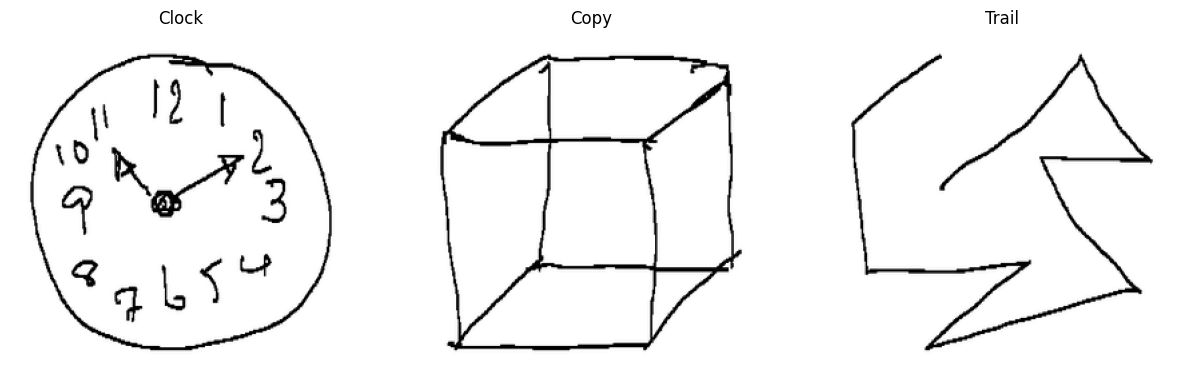

Label : 1
MoCA : 24.0
Train : 642 patients
Validation : 138 patients
Test : 138 patients

Class Weights
tensor([0.7055, 1.7166], device='cuda:0')

Batch Shapes
Clock : torch.Size([16, 3, 224, 224])
Copy  : torch.Size([16, 3, 224, 224])
Trail : torch.Size([16, 3, 224, 224])
Label : torch.Size([16])
Downloading: "https://download.pytorch.org/models/convnext_tiny-983f1562.pth" to /root/.cache/torch/hub/checkpoints/convnext_tiny-983f1562.pth


100%|██████████| 109M/109M [00:00<00:00, 162MB/s] 


Model Summary
Backbone : convnext_tiny
Trainable Parameters : 27,539,586
Total Parameters     : 29,071,842
Training Components Ready
Loss Function : FocalLoss
Optimizer     : AdamW
Scheduler     : ReduceLROnPlateau
EarlyStopping : Patience = 10
Training Started


  0%|          | 0/40 [00:00<?, ?it/s]

  0%|          | 0/9 [00:00<?, ?it/s]

...

Epoch 15/50 | Train Loss 0.1207 | Train Acc 0.7422 | Val Loss 0.1662 | Val Acc 0.6594 | Val AUC 0.7902 | LR 2.50e-05
EarlyStopping: 10/10

Early stopping activated.

Training Finished
Best Validation AUC : 0.7971
Loading Best Model


  0%|          | 0/9 [00:00<?, ?it/s]


Best Threshold = 0.60
Validation F1 = 0.6292


  0%|          | 0/9 [00:00<?, ?it/s]


TEST RESULTS
Threshold   : 0.60
Test Loss   : 0.1859
Accuracy    : 0.7246
Precision   : 0.5238
Recall      : 0.5500
Specificity : 0.7959
F1 Score    : 0.5366
ROC AUC     : 0.7375

Confusion Matrix
[[78 20]
 [18 22]]

Classification Report

              precision    recall  f1-score   support

      Normal       0.81      0.80      0.80        98
         MCI       0.52      0.55      0.54        40

    accuracy                           0.72       138
   macro avg       0.67      0.67      0.67       138
weighted avg       0.73      0.72      0.73       138


Metrics saved to
/content/drive/MyDrive/MCI_Results_convnext_tiny/test_metrics.csv


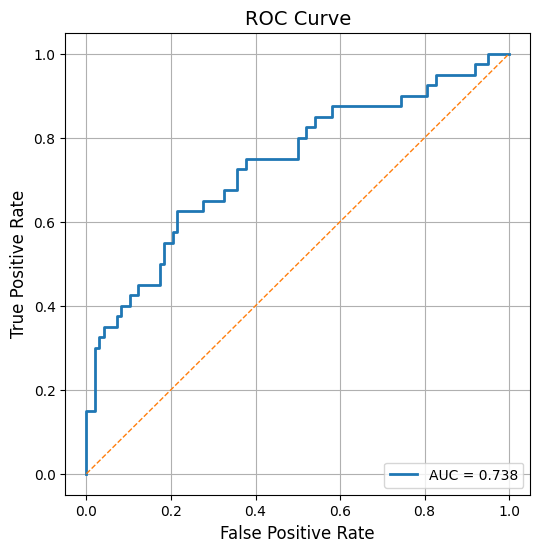

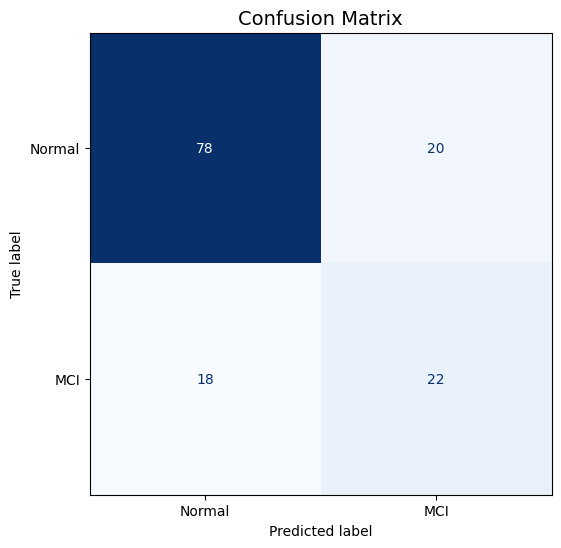

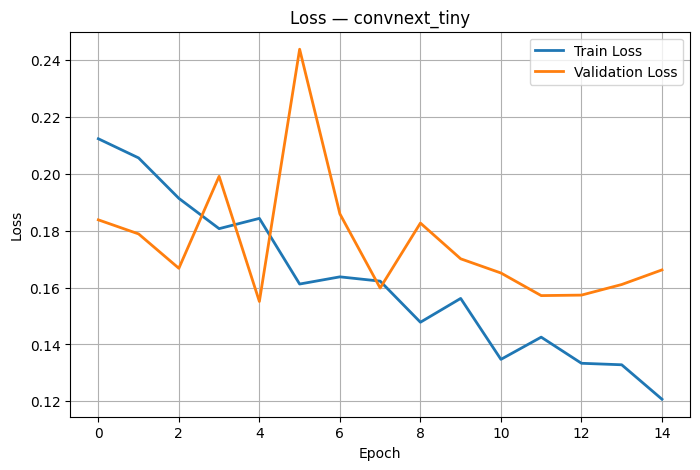

Results Saved
ROC Curve          : /content/drive/MyDrive/MCI_Results_convnext_tiny/roc_curve.png
Confusion Matrix   : /content/drive/MyDrive/MCI_Results_convnext_tiny/confusion_matrix.png
Predictions CSV    : /content/drive/MyDrive/MCI_Results_convnext_tiny/test_predictions.csv
Loss Curve         : /content/drive/MyDrive/MCI_Results_convnext_tiny/loss_curve.png
Metrics CSV        : /content/drive/MyDrive/MCI_Results_convnext_tiny/test_metrics.csv


In [ ]:
# -----------------------------
# Standard libraries
# -----------------------------
import os, json, random, warnings, platform
import numpy as np
import pandas as pd
from PIL import Image

warnings.filterwarnings("ignore")

# -----------------------------
# PyTorch / TorchVision
# -----------------------------
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torch.cuda.amp import autocast, GradScaler

import torchvision
from torchvision import transforms
import torchvision.models as models

# -----------------------------
# Sklearn
# -----------------------------
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, classification_report,
    roc_curve, auc, ConfusionMatrixDisplay,
)
from sklearn.utils.class_weight import compute_class_weight

# -----------------------------
# Viz / progress
# -----------------------------
import matplotlib.pyplot as plt
from tqdm.auto import tqdm

# ==========================================================
# SEED / DEVICE
# ==========================================================

SEED = 42
random.seed(SEED); np.random.seed(SEED)
torch.manual_seed(SEED); torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("=" * 60)
print("Device :", DEVICE)
if DEVICE.type == "cuda":
    print("GPU :", torch.cuda.get_device_name(0))
print("=" * 60)

# ==========================================================
# PATHS
# ==========================================================

DATASET_ROOT = "/content/drive/MyDrive/MCI_dataset"
TRAIN_CSV = os.path.join(DATASET_ROOT, "split/train.csv")
VAL_CSV   = os.path.join(DATASET_ROOT, "split/val.csv")
TEST_CSV  = os.path.join(DATASET_ROOT, "split/test.csv")

# ==========================================================
# MODEL / TRAINING CONFIG — change BACKBONE for experiments
# ==========================================================

BACKBONE = "convnext_tiny"    # "efficientnet_b3", "densenet121", "vit_b16", or "convnext_tiny"
OUTPUT_DIR = f"/content/drive/MyDrive/MCI_Results_{BACKBONE}"
os.makedirs(OUTPUT_DIR, exist_ok=True)
CHECKPOINT_PATH = os.path.join(OUTPUT_DIR, "best_model.pth")

NUM_CLASSES = 2
IMAGE_SIZE = 300 if BACKBONE == "efficientnet_b3" else 224
BATCH_SIZE = 16
NUM_WORKERS = 2
EPOCHS = 50
LEARNING_RATE = 1e-4
WEIGHT_DECAY = 1e-4
UNFREEZE_FRACTION = 0.30       # fraction of backbone conv-block stack to fine-tune
GRAD_CLIP_NORM = 1.0
EARLY_STOPPING_PATIENCE = 10
USE_AMP = torch.cuda.is_available()

print("\nConfiguration")
print("-" * 60)
print(f"Backbone        : {BACKBONE}")
print(f"Image Size      : {IMAGE_SIZE}")
print(f"Batch Size      : {BATCH_SIZE}")
print(f"Epochs          : {EPOCHS}")
print(f"Learning Rate   : {LEARNING_RATE}")
print(f"Weight Decay    : {WEIGHT_DECAY}")
print(f"Unfreeze Frac.  : {UNFREEZE_FRACTION}")
print(f"Mixed Precision : {USE_AMP}")
print("-" * 60)


def save_run_manifest():
    manifest = {
        "backbone": BACKBONE, "seed": SEED, "image_size": IMAGE_SIZE,
        "batch_size": BATCH_SIZE, "epochs": EPOCHS,
        "unfreeze_fraction": UNFREEZE_FRACTION,
        "learning_rate": LEARNING_RATE, "weight_decay": WEIGHT_DECAY,
        "grad_clip_norm": GRAD_CLIP_NORM,
        "torch_version": torch.__version__,
        "torchvision_version": torchvision.__version__,
        "python_version": platform.python_version(),
        "cuda_available": torch.cuda.is_available(),
        "gpu_name": torch.cuda.get_device_name(0) if torch.cuda.is_available() else None,
    }
    with open(os.path.join(OUTPUT_DIR, "run_manifest.json"), "w") as f:
        json.dump(manifest, f, indent=2)
    print("Run manifest saved to", os.path.join(OUTPUT_DIR, "run_manifest.json"))


save_run_manifest()

# ==========================================================
# DATASET
# ==========================================================

class MCIDataset(Dataset):
    def __init__(self, csv_file, transform=None):
        self.df = pd.read_csv(csv_file, dtype={"patient_id": str}).reset_index(drop=True)
        self.transform = transform
        print(f"{os.path.basename(csv_file)} : {len(self.df)} patients")

    def __len__(self):
        return len(self.df)

    def load_image(self, image_path):
        image = Image.open(image_path).convert("RGB")
        if self.transform is not None:
            image = self.transform(image)
        return image

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        return {
            "patient_id": row["patient_id"],
            "clock": self.load_image(row["clock_path"]),
            "copy": self.load_image(row["copy_path"]),
            "trail": self.load_image(row["trail_path"]),
            "label": torch.tensor(int(row["label"]), dtype=torch.long),
            "moca": float(row["MoCA_score"]),
        }


train_df = pd.read_csv(TRAIN_CSV)
val_df = pd.read_csv(VAL_CSV)
test_df = pd.read_csv(TEST_CSV)

print()
print("Train :", len(train_df))
print("Validation :", len(val_df))
print("Test :", len(test_df))
print()
print(train_df.head())

# ==========================================================
# TRANSFORMS
# NOTE: no RandomHorizontalFlip — clock numerals and trail
# direction are semantically meaningful and mirroring them
# would corrupt the diagnostic signal.
# ==========================================================

IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD = [0.229, 0.224, 0.225]

train_transform = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.RandomRotation(10),
    transforms.RandomAffine(degrees=0, translate=(0.05, 0.05), scale=(0.9, 1.1)),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(),
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
])

val_transform = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
])

train_dataset = MCIDataset(TRAIN_CSV, transform=train_transform)
val_dataset   = MCIDataset(VAL_CSV,   transform=val_transform)
test_dataset  = MCIDataset(TEST_CSV,  transform=val_transform)

# Sanity check — transformed sample should be a tensor
sample = train_dataset[0]
print()
print(sample["patient_id"], sample["label"], sample["moca"])
print(type(sample["clock"]), type(sample["copy"]), type(sample["trail"]))

# Preview raw (untransformed) images from a separate dataset instance
preview_dataset = MCIDataset(TRAIN_CSV, transform=None)
patient = preview_dataset[0]

plt.figure(figsize=(15, 5))
plt.subplot(1, 3, 1); plt.imshow(patient["clock"]); plt.title("Clock"); plt.axis("off")
plt.subplot(1, 3, 2); plt.imshow(patient["copy"]);  plt.title("Copy");  plt.axis("off")
plt.subplot(1, 3, 3); plt.imshow(patient["trail"]); plt.title("Trail"); plt.axis("off")
plt.show()
print("Label :", patient["label"].item())
print("MoCA :", patient["moca"])

# ==========================================================
# DATALOADERS
# drop_last=True on TRAIN ONLY: the classifier head has
# BatchNorm1d layers, which crash on a batch of size 1. A
# size-1 final batch happens whenever
# len(train_dataset) % BATCH_SIZE == 1 — silent otherwise.
# Val/test keep every sample since we want every prediction
# for correct metrics, and eval-mode BatchNorm uses running
# stats so a small last batch there is not a problem.
# ==========================================================

PIN_MEMORY = True

train_loader = DataLoader(
    train_dataset, batch_size=BATCH_SIZE, shuffle=True,
    num_workers=NUM_WORKERS, pin_memory=PIN_MEMORY,
    persistent_workers=(NUM_WORKERS > 0), drop_last=True,
)
val_loader = DataLoader(
    val_dataset, batch_size=BATCH_SIZE, shuffle=False,
    num_workers=NUM_WORKERS, pin_memory=PIN_MEMORY,
    persistent_workers=(NUM_WORKERS > 0),
)
test_loader = DataLoader(
    test_dataset, batch_size=BATCH_SIZE, shuffle=False,
    num_workers=NUM_WORKERS, pin_memory=PIN_MEMORY,
    persistent_workers=(NUM_WORKERS > 0),
)

print(f"Train : {len(train_dataset)} patients")
print(f"Validation : {len(val_dataset)} patients")
print(f"Test : {len(test_dataset)} patients")

class_weights = compute_class_weight(
    class_weight="balanced", classes=np.unique(train_df["label"]), y=train_df["label"]
)
class_weights = torch.tensor(class_weights, dtype=torch.float32, device=DEVICE)
print("\nClass Weights"); print(class_weights)

batch = next(iter(train_loader))
print("\nBatch Shapes")
print("Clock :", batch["clock"].shape)
print("Copy  :", batch["copy"].shape)
print("Trail :", batch["trail"].shape)
print("Label :", batch["label"].shape)

# ==========================================================
# MODEL
# ==========================================================

def build_backbone(name):
    if name.lower() == "efficientnet_b3":
        weights = models.EfficientNet_B3_Weights.IMAGENET1K_V1
        backbone = models.efficientnet_b3(weights=weights)
        feature_dim = backbone.classifier[1].in_features
        backbone.classifier = nn.Identity()
    elif name.lower() == "densenet121":
        weights = models.DenseNet121_Weights.IMAGENET1K_V1
        backbone = models.densenet121(weights=weights)
        feature_dim = backbone.classifier.in_features
        backbone.classifier = nn.Identity()
    elif name.lower() == "vit_b16":
        weights = models.ViT_B_16_Weights.IMAGENET1K_V1
        backbone = models.vit_b_16(weights=weights)
        feature_dim = backbone.heads.head.in_features   # 768 for ViT-B/16
        backbone.heads.head = nn.Identity()
    elif name.lower() == "convnext_tiny":
        weights = models.ConvNeXt_Tiny_Weights.IMAGENET1K_V1
        backbone = models.convnext_tiny(weights=weights)
        # classifier = Sequential(LayerNorm2d, Flatten, Linear) — only
        # replace the final Linear. Replacing the whole `classifier`
        # (as with DenseNet) would also drop the LayerNorm2d + Flatten
        # steps that torchvision's forward() relies on to turn pooled
        # conv features into a flat, normalized vector.
        feature_dim = backbone.classifier[-1].in_features   # 768 for ConvNeXt-Tiny
        backbone.classifier[-1] = nn.Identity()
    else:
        raise ValueError("Unsupported backbone")
    return backbone, feature_dim


class MCIClassifier(nn.Module):

    def __init__(self, backbone_name="efficientnet_b3", num_classes=2,
                 unfreeze_fraction=0.30):
        super().__init__()

        self.backbone_name = backbone_name.lower()
        self.backbone, feature_dim = build_backbone(backbone_name)

        # Freeze everything first.
        for param in self.backbone.parameters():
            param.requires_grad = False

        # FIX: unfreeze the last `unfreeze_fraction` of the actual
        # block stack for this architecture — NOT backbone.children(),
        # which for EfficientNet/DenseNet/ConvNeXt is only 2-3
        # top-level blocks (features/avgpool/classifier), and for ViT
        # is also only a handful of top-level modules
        # (conv_proj/encoder/heads). Using backbone.children() silently
        # unfreezes only the empty Identity() head and leaves every
        # real layer frozen — i.e. no fine-tuning happens at all.
        if self.backbone_name in ("densenet121", "efficientnet_b3", "convnext_tiny"):
            block_children = list(self.backbone.features.children())
        elif self.backbone_name == "vit_b16":
            # ViT has no conv "features" stack — its 12 transformer
            # encoder blocks live at backbone.encoder.layers.
            block_children = list(self.backbone.encoder.layers.children())
        else:
            raise ValueError("Unsupported backbone")

        n = len(block_children)
        start = int(n * (1 - unfreeze_fraction))
        for child in block_children[start:]:
            for param in child.parameters():
                param.requires_grad = True

        # For ViT, also unfreeze the final encoder LayerNorm whenever
        # any encoder layers are trainable — leaving it frozen while
        # the layers feeding it are being fine-tuned tends to hurt
        # training stability.
        if self.backbone_name == "vit_b16" and unfreeze_fraction > 0:
            for param in self.backbone.encoder.ln.parameters():
                param.requires_grad = True

        fusion_dim = feature_dim * 3
        self.classifier = nn.Sequential(
            nn.BatchNorm1d(fusion_dim), nn.Dropout(0.50),
            nn.Linear(fusion_dim, 512), nn.ReLU(inplace=True),
            nn.BatchNorm1d(512), nn.Dropout(0.40),
            nn.Linear(512, 128), nn.ReLU(inplace=True),
            nn.Dropout(0.30), nn.Linear(128, num_classes),
        )

    def forward(self, clock, copy, trail):
        # Calling self.backbone(x) directly is correct here: both
        # EfficientNet's and DenseNet's own forward() already do
        # pool -> flatten -> classifier(Identity) internally, so no
        # manual pooling step is needed (unlike scripts that call
        # backbone.features(x) directly, which skips that step).
        f1 = self.backbone(clock)
        f2 = self.backbone(copy)
        f3 = self.backbone(trail)
        fusion = torch.cat([f1, f2, f3], dim=1)
        return self.classifier(fusion)


model = MCIClassifier(BACKBONE, NUM_CLASSES, UNFREEZE_FRACTION).to(DEVICE)

trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
total = sum(p.numel() for p in model.parameters())
print("=" * 60)
print("Model Summary")
print("=" * 60)
print("Backbone :", BACKBONE)
print(f"Trainable Parameters : {trainable:,}")
print(f"Total Parameters     : {total:,}")
print("=" * 60)

# ==========================================================
# LOSS / OPTIMIZER / SCHEDULER
# ==========================================================

class FocalLoss(nn.Module):
    def __init__(self, alpha=None, gamma=2.0, reduction="mean"):
        super().__init__()
        self.alpha, self.gamma, self.reduction = alpha, gamma, reduction

    def forward(self, inputs, targets):
        ce_loss = nn.functional.cross_entropy(inputs, targets, weight=self.alpha, reduction="none")
        pt = torch.exp(-ce_loss)
        focal_loss = ((1 - pt) ** self.gamma) * ce_loss
        if self.reduction == "mean":
            return focal_loss.mean()
        elif self.reduction == "sum":
            return focal_loss.sum()
        return focal_loss


criterion = FocalLoss(alpha=class_weights, gamma=2.0)

optimizer = optim.AdamW(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY,
)

scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode="min", factor=0.5, patience=3)
scaler = GradScaler(enabled=USE_AMP)


class EarlyStopping:
    def __init__(self, patience=10, min_delta=0.0):
        self.patience, self.min_delta = patience, min_delta
        self.counter, self.best_loss, self.stop = 0, float("inf"), False

    def __call__(self, val_loss):
        if val_loss < self.best_loss - self.min_delta:
            self.best_loss, self.counter = val_loss, 0
        else:
            self.counter += 1
            print(f"EarlyStopping: {self.counter}/{self.patience}")
            if self.counter >= self.patience:
                self.stop = True


early_stopping = EarlyStopping(patience=EARLY_STOPPING_PATIENCE)
history = {"train_loss": [], "train_acc": [], "val_loss": [], "val_acc": [], "val_auc": [], "lr": []}

print("=" * 60)
print("Training Components Ready")
print("=" * 60)
print("Loss Function :", criterion.__class__.__name__)
print("Optimizer     : AdamW")
print("Scheduler     : ReduceLROnPlateau")
print("EarlyStopping : Patience =", early_stopping.patience)
print("=" * 60)

# ==========================================================
# TRAIN / VALIDATE
# ==========================================================

def train_one_epoch(model, loader):
    model.train()
    running_loss, running_correct, total = 0.0, 0, 0
    loop = tqdm(loader, leave=False)
    for batch in loop:
        clock = batch["clock"].to(DEVICE, non_blocking=True)
        copy = batch["copy"].to(DEVICE, non_blocking=True)
        trail = batch["trail"].to(DEVICE, non_blocking=True)
        labels = batch["label"].to(DEVICE)

        optimizer.zero_grad()
        with autocast(enabled=USE_AMP):
            outputs = model(clock, copy, trail)
            loss = criterion(outputs, labels)

        scaler.scale(loss).backward()
        # Grad clipping for stability — must unscale first when using AMP.
        scaler.unscale_(optimizer)
        torch.nn.utils.clip_grad_norm_(model.parameters(), GRAD_CLIP_NORM)
        scaler.step(optimizer)
        scaler.update()

        preds = outputs.argmax(dim=1)
        running_loss += loss.item() * labels.size(0)
        running_correct += (preds == labels).sum().item()
        total += labels.size(0)
        loop.set_postfix(loss=f"{loss.item():.4f}", acc=f"{100*running_correct/total:.2f}%")

    return running_loss / total, running_correct / total


def validate(model, loader):
    model.eval()
    running_loss, running_correct, total = 0.0, 0, 0
    y_true, y_prob = [], []
    with torch.no_grad():
        for batch in tqdm(loader, leave=False):
            clock = batch["clock"].to(DEVICE, non_blocking=True)
            copy = batch["copy"].to(DEVICE, non_blocking=True)
            trail = batch["trail"].to(DEVICE, non_blocking=True)
            labels = batch["label"].to(DEVICE)

            with autocast(enabled=USE_AMP):
                outputs = model(clock, copy, trail)
                loss = criterion(outputs, labels)

            probs = torch.softmax(outputs, dim=1)
            preds = outputs.argmax(dim=1)
            running_loss += loss.item() * labels.size(0)
            running_correct += (preds == labels).sum().item()
            total += labels.size(0)
            y_true.extend(labels.cpu().numpy())
            y_prob.extend(probs[:, 1].cpu().numpy())

    try:
        epoch_auc = roc_auc_score(y_true, y_prob)
    except Exception:
        epoch_auc = 0.5

    return running_loss / total, running_correct / total, epoch_auc


# ==========================================================
# TRAINING LOOP
# ==========================================================

print("=" * 70); print("Training Started"); print("=" * 70)
best_auc = 0.0

for epoch in range(EPOCHS):
    train_loss, train_acc = train_one_epoch(model, train_loader)
    val_loss, val_acc, val_auc = validate(model, val_loader)
    scheduler.step(val_loss)

    history["train_loss"].append(train_loss)
    history["train_acc"].append(train_acc)
    history["val_loss"].append(val_loss)
    history["val_acc"].append(val_acc)
    history["val_auc"].append(val_auc)
    history["lr"].append(optimizer.param_groups[0]["lr"])

    print(
        f"Epoch {epoch+1:02d}/{EPOCHS}"
        f" | Train Loss {train_loss:.4f}"
        f" | Train Acc {train_acc:.4f}"
        f" | Val Loss {val_loss:.4f}"
        f" | Val Acc {val_acc:.4f}"
        f" | Val AUC {val_auc:.4f}"
        f" | LR {optimizer.param_groups[0]['lr']:.2e}"
    )

    if val_auc > best_auc:
        best_auc = val_auc
        torch.save(model.state_dict(), CHECKPOINT_PATH)
        print("★★★★★ Best Model Updated ★★★★★")

    early_stopping(val_loss)
    if early_stopping.stop:
        print("\nEarly stopping activated.")
        break

print("\n" + "=" * 70)
print("Training Finished")
print("=" * 70)
print(f"Best Validation AUC : {best_auc:.4f}")

# ==========================================================
# TEST EVALUATION (threshold tuned on val)
# ==========================================================

print("=" * 60); print("Loading Best Model"); print("=" * 60)
model.load_state_dict(torch.load(CHECKPOINT_PATH))
model.eval()

val_probs, val_labels = [], []
with torch.no_grad():
    for batch in tqdm(val_loader):
        clock = batch["clock"].to(DEVICE)
        copy = batch["copy"].to(DEVICE)
        trail = batch["trail"].to(DEVICE)
        labels = batch["label"].cpu().numpy()
        outputs = model(clock, copy, trail)
        probs = torch.softmax(outputs, dim=1)[:, 1]
        val_probs.extend(probs.cpu().numpy())
        val_labels.extend(labels)

best_threshold, best_f1 = 0.50, 0
for t in np.arange(0.20, 0.81, 0.01):
    preds = (np.array(val_probs) >= t).astype(int)
    f1 = f1_score(val_labels, preds)
    if f1 > best_f1:
        best_f1, best_threshold = f1, t

print(f"\nBest Threshold = {best_threshold:.2f}")
print(f"Validation F1 = {best_f1:.4f}")

test_probs, test_preds, test_labels = [], [], []
running_loss, total = 0, 0
with torch.no_grad():
    for batch in tqdm(test_loader):
        clock = batch["clock"].to(DEVICE)
        copy = batch["copy"].to(DEVICE)
        trail = batch["trail"].to(DEVICE)
        labels = batch["label"].to(DEVICE)

        outputs = model(clock, copy, trail)
        loss = criterion(outputs, labels)
        probs = torch.softmax(outputs, dim=1)[:, 1]
        preds = (probs >= best_threshold).long()

        running_loss += loss.item() * labels.size(0)
        total += labels.size(0)
        test_probs.extend(probs.cpu().numpy())
        test_preds.extend(preds.cpu().numpy())
        test_labels.extend(labels.cpu().numpy())

test_loss = running_loss / total
accuracy = accuracy_score(test_labels, test_preds)
precision = precision_score(test_labels, test_preds)
recall = recall_score(test_labels, test_preds)
f1 = f1_score(test_labels, test_preds)
test_auc = roc_auc_score(test_labels, test_probs)
cm = confusion_matrix(test_labels, test_preds)
tn, fp, fn, tp = cm.ravel()
specificity = tn / (tn + fp)

print("\n" + "=" * 70)
print("TEST RESULTS")
print("=" * 70)
print(f"Threshold   : {best_threshold:.2f}")
print(f"Test Loss   : {test_loss:.4f}")
print(f"Accuracy    : {accuracy:.4f}")
print(f"Precision   : {precision:.4f}")
print(f"Recall      : {recall:.4f}")
print(f"Specificity : {specificity:.4f}")
print(f"F1 Score    : {f1:.4f}")
print(f"ROC AUC     : {test_auc:.4f}")
print("=" * 70)
print("\nConfusion Matrix"); print(cm)
print("\nClassification Report\n")
print(classification_report(test_labels, test_preds, target_names=["Normal", "MCI"]))

metrics = pd.DataFrame({
    "Accuracy": [accuracy], "Precision": [precision], "Recall": [recall],
    "Specificity": [specificity], "F1": [f1], "AUC": [test_auc],
    "Threshold": [best_threshold],
})
metrics_path = os.path.join(OUTPUT_DIR, "test_metrics.csv")
metrics.to_csv(metrics_path, index=False)
print("\nMetrics saved to"); print(metrics_path)

# ==========================================================
# ROC CURVE, CONFUSION MATRIX, PREDICTIONS
# ==========================================================

fpr, tpr, _ = roc_curve(test_labels, test_probs)
roc_auc_val = auc(fpr, tpr)

plt.figure(figsize=(6, 6))
plt.plot(fpr, tpr, lw=2, label=f"AUC = {roc_auc_val:.3f}")
plt.plot([0, 1], [0, 1], linestyle="--", linewidth=1)
plt.xlabel("False Positive Rate", fontsize=12)
plt.ylabel("True Positive Rate", fontsize=12)
plt.title("ROC Curve", fontsize=14)
plt.legend(loc="lower right")
plt.grid(True)
roc_path = os.path.join(OUTPUT_DIR, "roc_curve.png")
plt.savefig(roc_path, dpi=300, bbox_inches="tight")
plt.show()

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Normal", "MCI"])
fig, ax = plt.subplots(figsize=(6, 6))
disp.plot(cmap="Blues", ax=ax, colorbar=False, values_format="d")
plt.title("Confusion Matrix", fontsize=14)
cm_path = os.path.join(OUTPUT_DIR, "confusion_matrix.png")
plt.savefig(cm_path, dpi=300, bbox_inches="tight")
plt.show()

predictions = pd.DataFrame({
    "True_Label": test_labels, "Predicted_Label": test_preds, "Probability_MCI": test_probs
})
prediction_path = os.path.join(OUTPUT_DIR, "test_predictions.csv")
predictions.to_csv(prediction_path, index=False)

# Loss/accuracy curves — useful for spotting overfitting at a glance
plt.figure(figsize=(8, 5))
plt.plot(history["train_loss"], label="Train Loss", linewidth=2)
plt.plot(history["val_loss"], label="Validation Loss", linewidth=2)
plt.xlabel("Epoch"); plt.ylabel("Loss"); plt.title(f"Loss — {BACKBONE}")
plt.legend(); plt.grid(True)
loss_curve_path = os.path.join(OUTPUT_DIR, "loss_curve.png")
plt.savefig(loss_curve_path, dpi=300, bbox_inches="tight")
plt.show()

print("=" * 60)
print("Results Saved")
print("=" * 60)
print("ROC Curve          :", roc_path)
print("Confusion Matrix   :", cm_path)
print("Predictions CSV    :", prediction_path)
print("Loss Curve         :", loss_curve_path)
print("Metrics CSV        :", metrics_path)